# Lab 05: Image Segmentation

In [46]:
import os
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

os.makedirs("outputs", exist_ok=True)

---
## Task 1: Automated Inspection of a Document Under Uneven Lighting

**Parameters**

| Parameter | Value | Why |
|---|---|---|
| Global T1 | 50 | Targets only the darkest ink |
| Global T2 | 90 | Close to Otsu's own pick for this image |
| Global T3 | 130 | High, to catch faint ink on the bright side |
| Adaptive | Gaussian, blockSize=51, C=5 | Window wide enough to follow the lighting gradient, C keeps paper grain out |

In [47]:
t1_gray = cv2.imread("images/sudoku.png", cv2.IMREAD_GRAYSCALE)
print("Image size:", t1_gray.shape, "| min:", t1_gray.min(), "| max:", t1_gray.max(), "| mean:", round(t1_gray.mean(), 1))

t1_thresholds = [50, 90, 130]
t1_global_masks = [cv2.threshold(t1_gray, t1_value, 255, cv2.THRESH_BINARY)[1] for t1_value in t1_thresholds]

t1_block_size = 51
t1_c = 5
t1_adaptive_mask = cv2.adaptiveThreshold(
    t1_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, t1_block_size, t1_c
)

Image size: (563, 558) | min: 7 | max: 218 | mean: 101.8


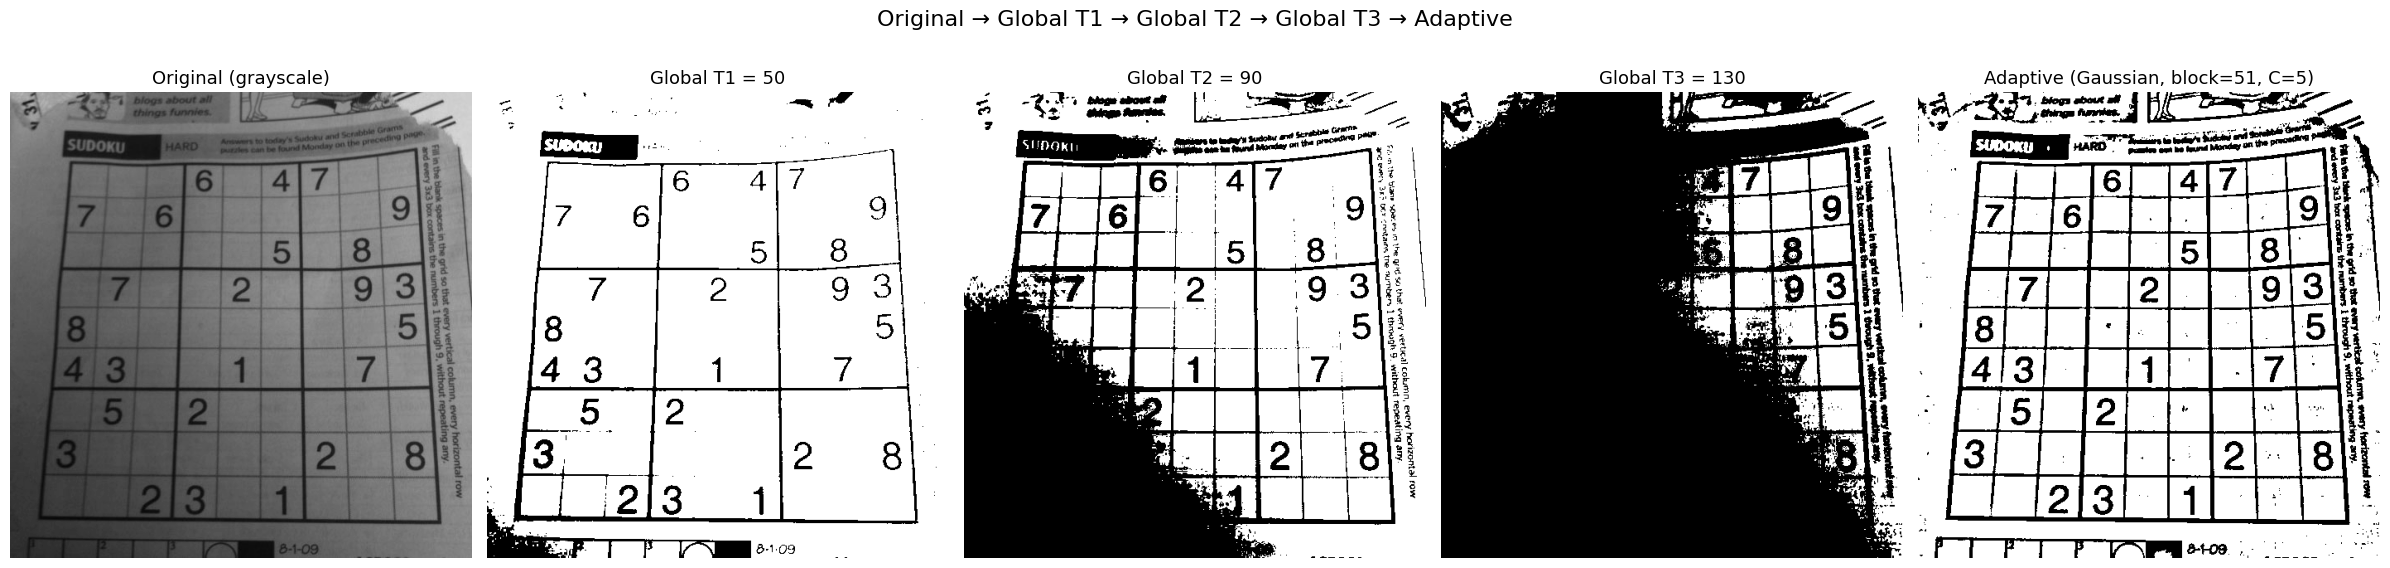

True

In [48]:
t1_images = [t1_gray] + t1_global_masks + [t1_adaptive_mask]
t1_titles = (
    ["Original (grayscale)"]
    + [f"Global T{t1_idx + 1} = {t1_val}" for t1_idx, t1_val in enumerate(t1_thresholds)]
    + [f"Adaptive (Gaussian, block={t1_block_size}, C={t1_c})"]
)

t1_fig, t1_axes = plt.subplots(1, 5, figsize=(24, 6.2))
for t1_ax, t1_img, t1_title in zip(t1_axes, t1_images, t1_titles):
    t1_ax.imshow(t1_img, cmap="gray", vmin=0, vmax=255)
    t1_ax.set_title(t1_title, fontsize=13)
    t1_ax.axis("off")

plt.suptitle("Original → Global T1 → Global T2 → Global T3 → Adaptive", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/task1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

cv2.imwrite("outputs/task1_final_adaptive_mask.png", t1_adaptive_mask)

In [49]:
m = t1_gray.shape[1]
for t1_img, t1_title in zip(t1_images, t1_titles):
    print(t1_title, ': black pixels left:', round(np.mean(t1_img[:, :m // 2] == 0), 3), 'right:', round(np.mean(t1_img[:, m // 2:] == 0), 3))

Original (grayscale) : black pixels left: 0.0 right: 0.0
Global T1 = 50 : black pixels left: 0.111 right: 0.055
Global T2 = 90 : black pixels left: 0.541 right: 0.152
Global T3 = 130 : black pixels left: 0.976 right: 0.58
Adaptive (Gaussian, block=51, C=5) : black pixels left: 0.185 right: 0.204


### Task 1 analysis

Image: 563x558, intensity 7-218 (mean 101.8) -- a wide spread, confirming uneven lighting.

**Black-pixel share, left half vs right half (left is the darker side of the page):**

| Mask | Left | Right |
|---|---|---|
| T1 = 50 | 11.1% | 5.5% |
| T2 = 90 | 54.1% | 15.2% |
| T3 = 130 | 97.6% | 58.0% |
| Adaptive | 18.5% | 20.4% |

Every global threshold is lopsided: raising it to cope with the dark left side floods the right side too (T3 turns both halves mostly black), and lowering it to protect the bright side starves the dark side of ink (T1). The adaptive mask is the only one that stays balanced (18.5% vs 20.4%), because it judges each pixel against its own neighbourhood instead of one page-wide cutoff.

**Best combination:** adaptive Gaussian thresholding, blockSize 51, C = 5.

**Why does a single threshold struggle when illumination changes across the image?** It assumes ink and paper share the same brightness everywhere. Under uneven light, shadowed paper can be as dark as lit ink, so no single cut value can separate them correctly on both sides at once. Adaptive thresholding sidesteps this by comparing each pixel only to its local neighbourhood, so the overall lighting trend cancels out.

---
## Task 2: Choosing the Correct Adaptive Threshold Strategy

**Parameters tested:** blockSize 11, 31, 71 and C = 2, 10, 20 -- small, medium and large on purpose, so the effect of each is easy to see.

In [50]:
t2_gray = cv2.imread("images/sudoku.png", cv2.IMREAD_GRAYSCALE)

t2_methods = {"Mean": cv2.ADAPTIVE_THRESH_MEAN_C, "Gaussian": cv2.ADAPTIVE_THRESH_GAUSSIAN_C}
t2_block_sizes = [11, 31, 71]
t2_c_values = [2, 10, 20]

t2_results = {}
for t2_name, t2_flag in t2_methods.items():
    for t2_bs in t2_block_sizes:
        for t2_cc in t2_c_values:
            t2_results[(t2_name, t2_bs, t2_cc)] = cv2.adaptiveThreshold(
                t2_gray, 255, t2_flag, cv2.THRESH_BINARY, t2_bs, t2_cc
            )
print("Number of adaptive results:", len(t2_results))

Number of adaptive results: 18


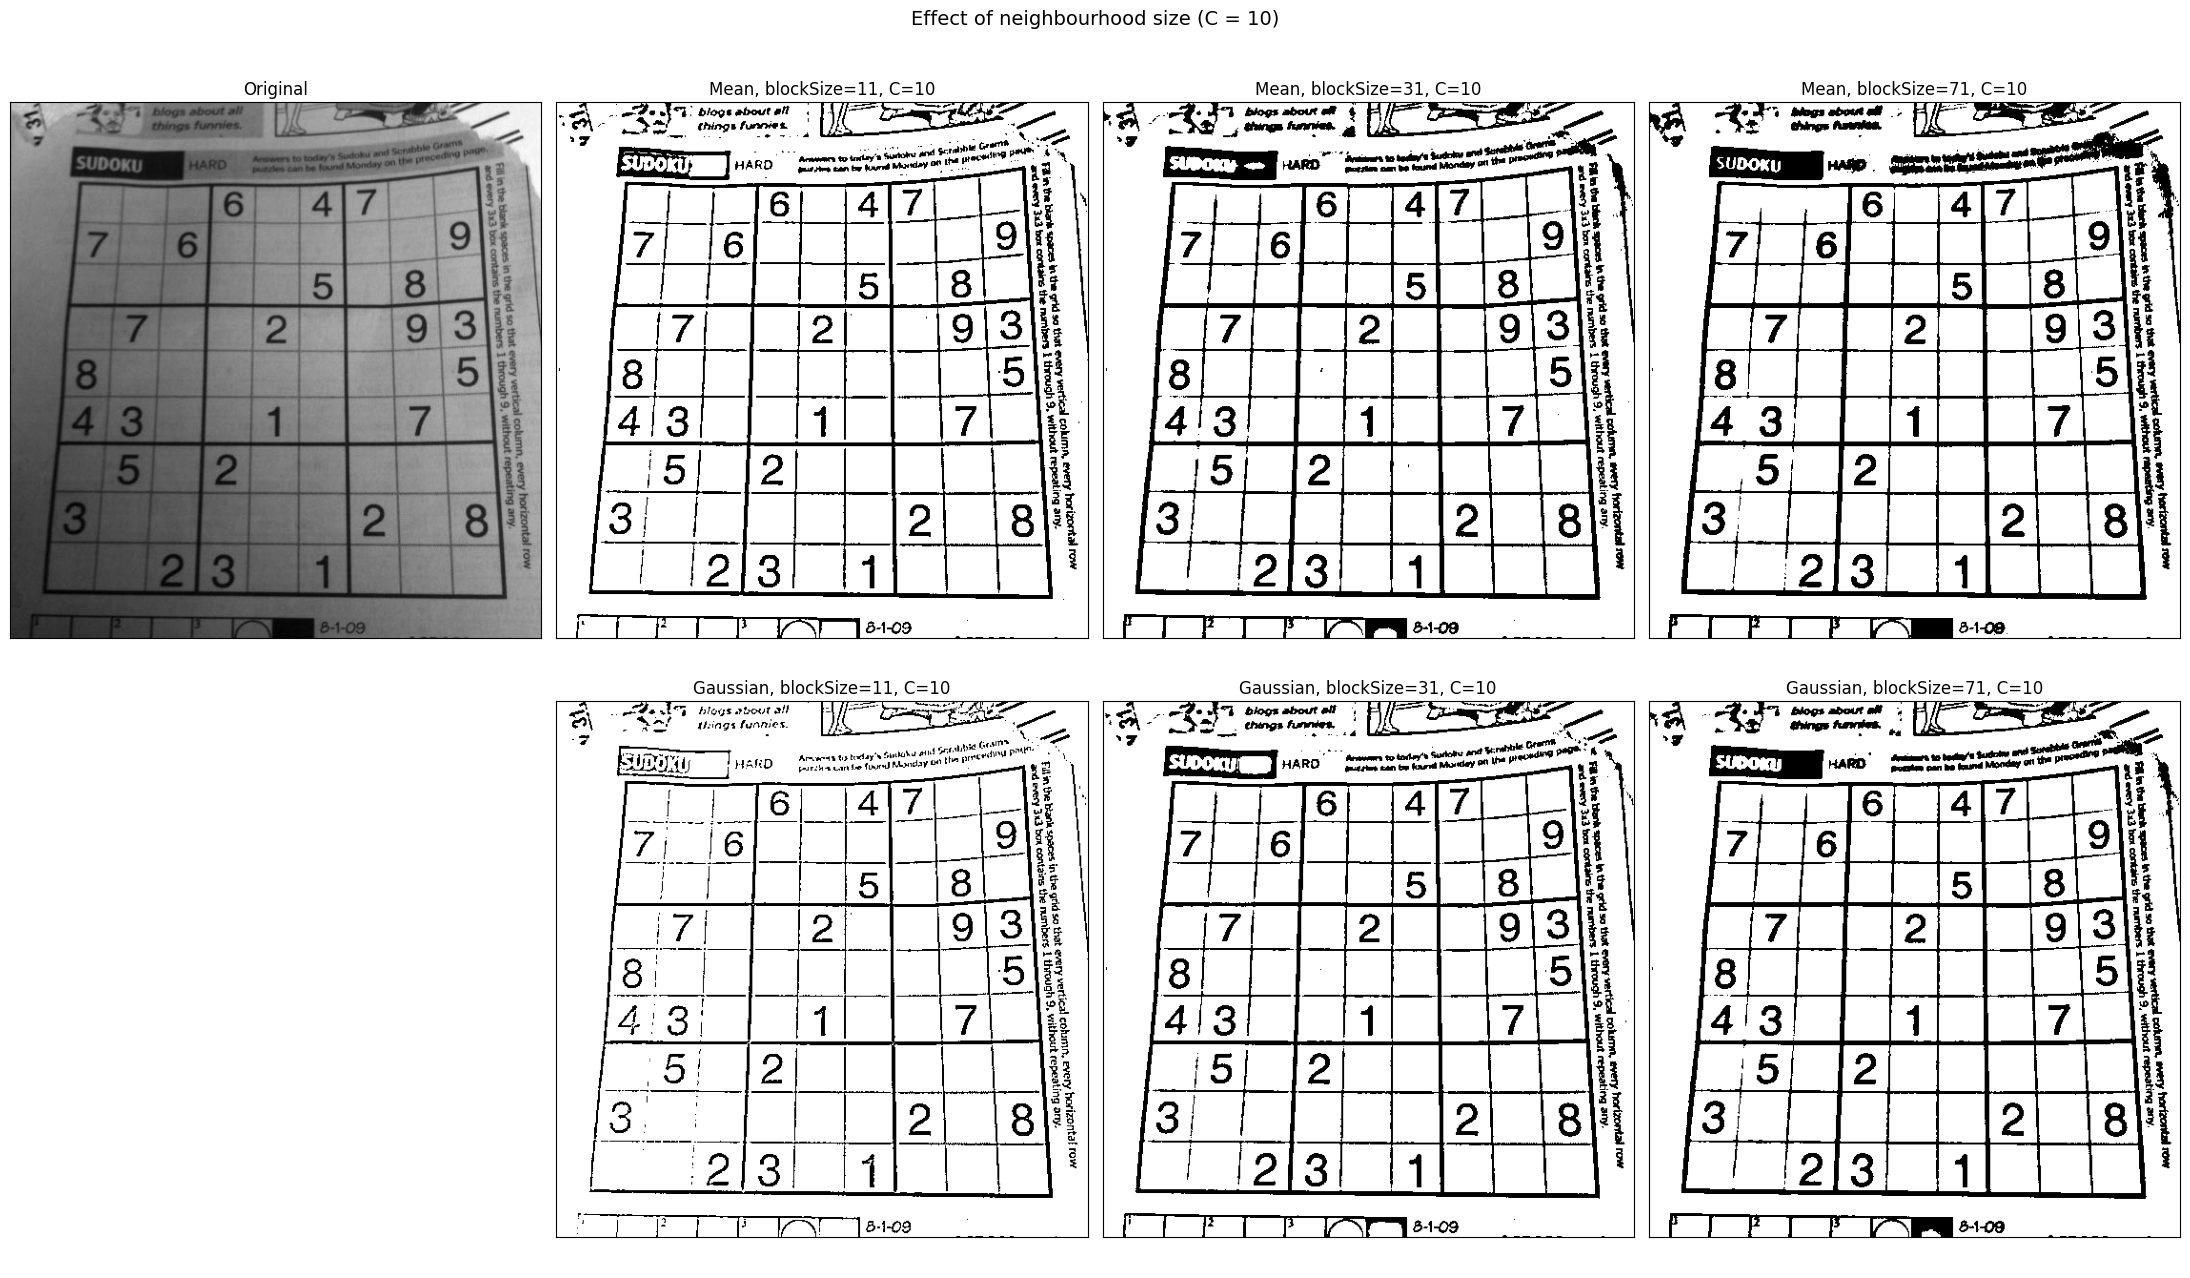

In [51]:
# 2 methods x 3 block sizes, C fixed at 10
t2_fig_a, t2_axes_a = plt.subplots(2, 4, figsize=(22, 13))
t2_axes_a[0, 0].imshow(t2_gray, cmap="gray")
t2_axes_a[0, 0].set_title("Original")
t2_axes_a[1, 0].axis("off")
for t2_row, t2_name in enumerate(t2_methods):
    for t2_col, t2_bs in enumerate(t2_block_sizes):
        t2_ax = t2_axes_a[t2_row, t2_col + 1]
        t2_ax.imshow(t2_results[(t2_name, t2_bs, 10)], cmap="gray")
        t2_ax.set_title(f"{t2_name}, blockSize={t2_bs}, C=10")
for t2_ax in t2_axes_a.ravel():
    t2_ax.set_xticks([])
    t2_ax.set_yticks([])
t2_fig_a.suptitle("Effect of neighbourhood size (C = 10)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.0)
t2_fig_a.savefig("outputs/task2_blocksize_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

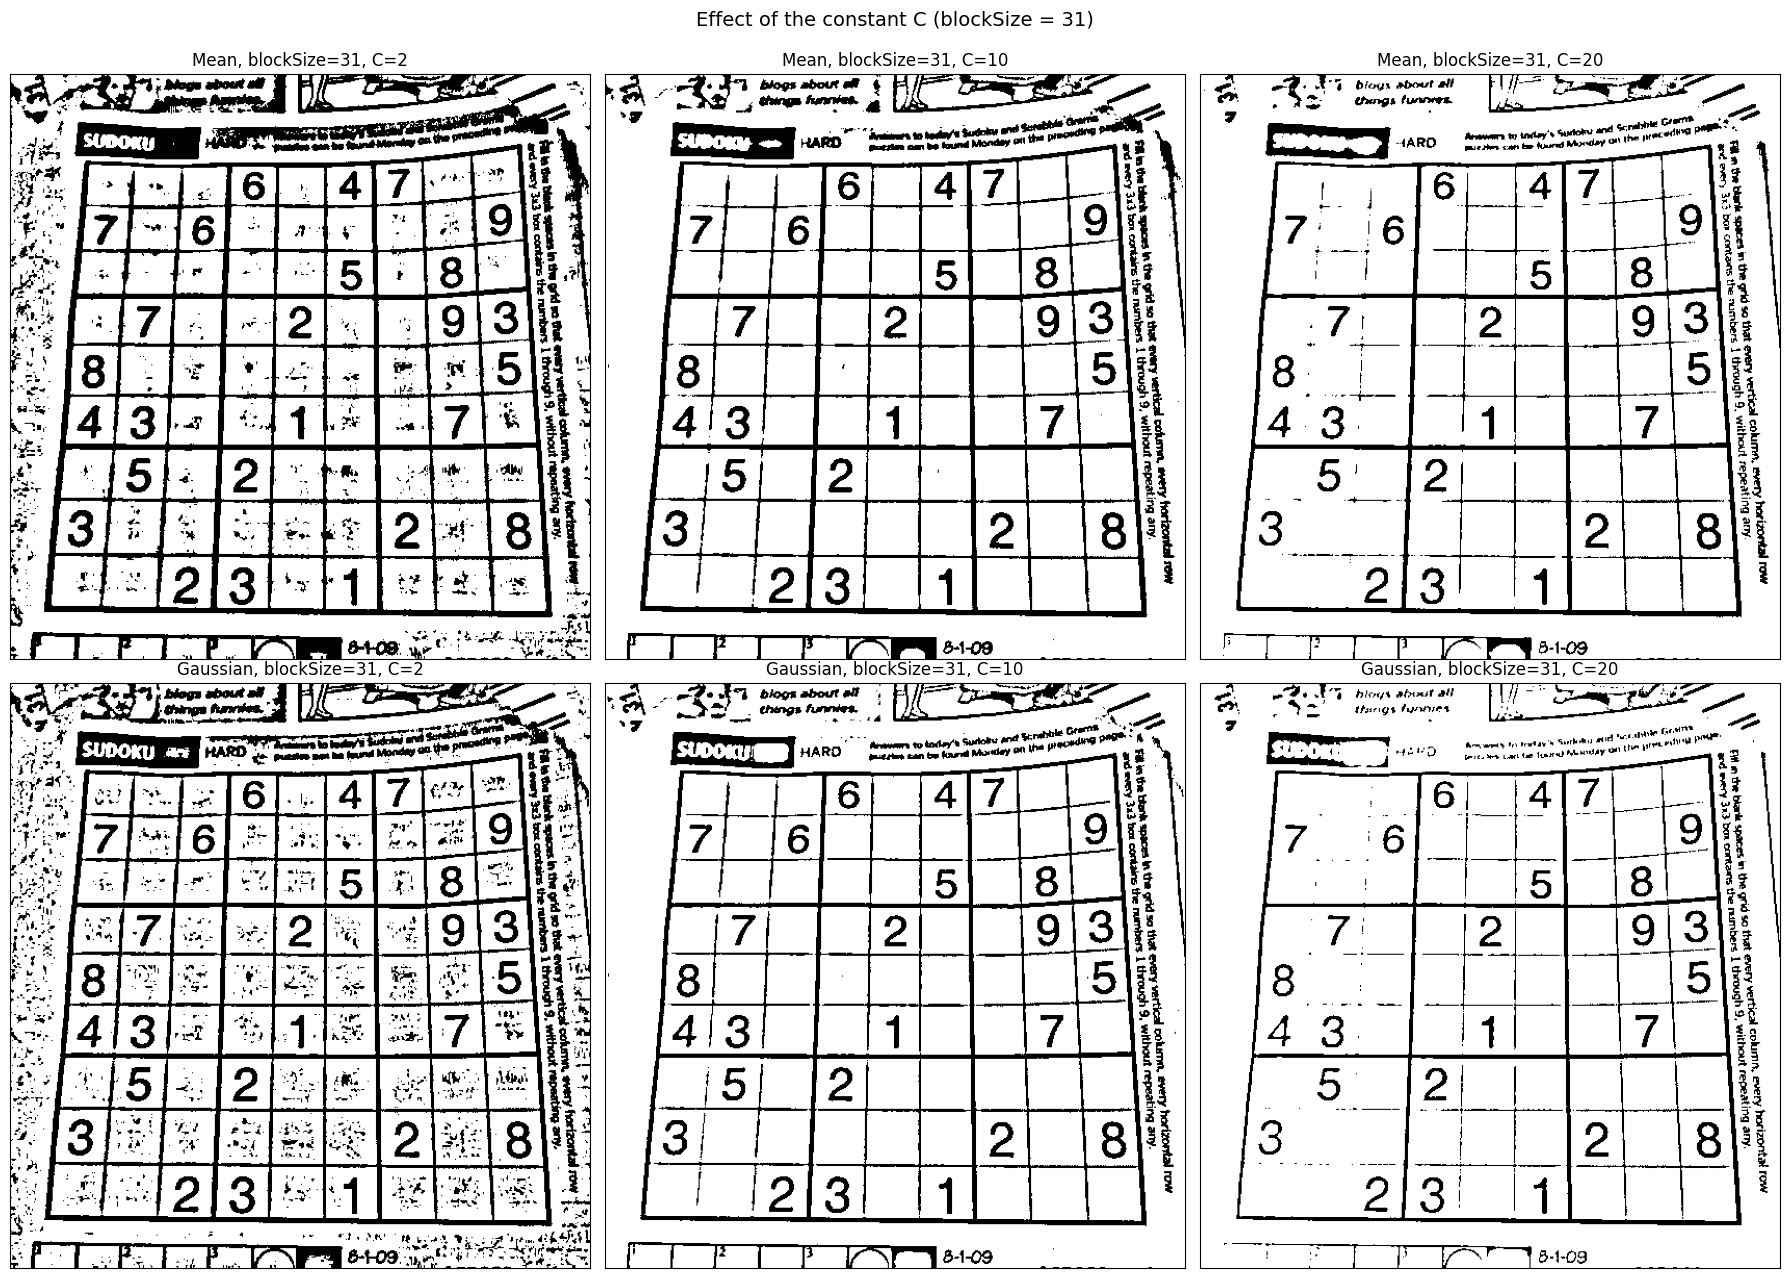

In [52]:
# effect of C at a fixed medium block size (31) for both methods
t2_fig_b, t2_axes_b = plt.subplots(2, 3, figsize=(18, 13))
for t2_row, t2_name in enumerate(t2_methods):
    for t2_col, t2_cc in enumerate(t2_c_values):
        t2_ax = t2_axes_b[t2_row, t2_col]
        t2_ax.imshow(t2_results[(t2_name, 31, t2_cc)], cmap="gray")
        t2_ax.set_title(f"{t2_name}, blockSize=31, C={t2_cc}")
        t2_ax.set_xticks([])
        t2_ax.set_yticks([])
t2_fig_b.suptitle("Effect of the constant C (blockSize = 31)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.0)
t2_fig_b.savefig("outputs/task2_C_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

In [53]:
t2_empty_patches = [(480, 505, 80, 106), (98, 122, 405, 440)]
t2_digit_patches = [(475, 508, 195, 240), (120, 165, 445, 490)]

t2_rows = []
for (t2_name, t2_bs, t2_cc), t2_mask in t2_results.items():
    t2_noise = np.mean([(t2_mask[t2_a:t2_b, t2_c:t2_d] > 0).mean() * 100 for t2_a, t2_b, t2_c, t2_d in t2_empty_patches])
    t2_ink = np.mean([(t2_mask[t2_a:t2_b, t2_c:t2_d] > 0).mean() * 100 for t2_a, t2_b, t2_c, t2_d in t2_digit_patches])
    t2_count = cv2.connectedComponents(t2_mask)[0] - 1
    t2_rows.append({
        "Method": t2_name, "blockSize": t2_bs, "C": t2_cc,
        "Noise in empty cells (%)": round(t2_noise, 1),
        "Ink in digit boxes (%)": round(t2_ink, 1),
        "Overall white (%)": round((t2_mask > 0).mean() * 100, 1),
        "White components": t2_count,
    })

t2_table = pd.DataFrame(t2_rows)
display(t2_table)
t2_table.to_csv("outputs/task2_parameter_table.csv", index=False)

,Method,blockSize,C,Noise in empty cells (%),Ink in digit boxes (%),Overall white (%),White components
0,Mean,11,2,79.4,67.7,74.4,210
1,Mean,11,10,96.0,73.1,85.7,112
2,Mean,11,20,99.3,78.0,90.4,58
3,Mean,31,2,85.8,65.9,75.1,279
4,Mean,31,10,94.6,69.6,82.6,199
5,Mean,31,20,99.2,74.5,87.2,100
6,Mean,71,2,90.7,65.2,75.4,302
7,Mean,71,10,96.0,69.0,81.5,206
8,Mean,71,20,99.1,73.7,85.9,136
9,Gaussian,11,2,84.1,67.7,77.6,214


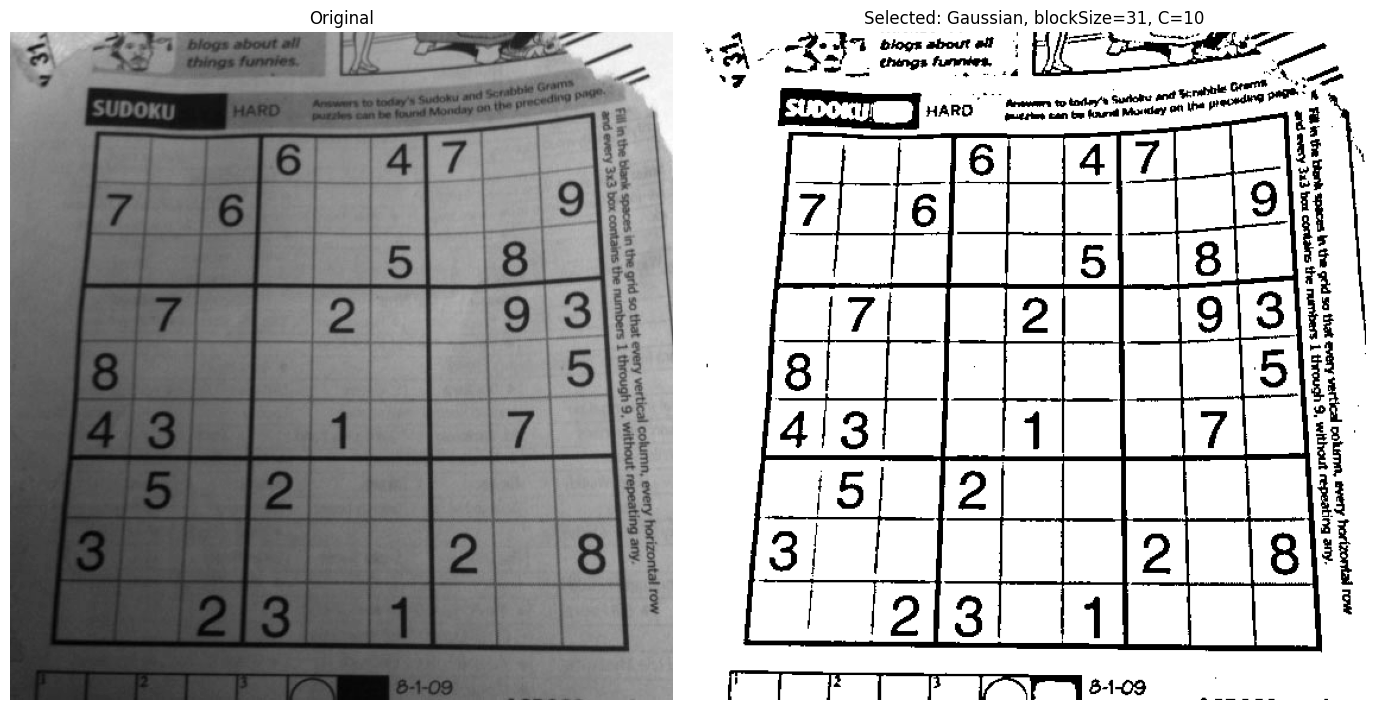

True

In [54]:
t2_best_method, t2_best_bs, t2_best_c = "Gaussian", 31, 10
t2_best_mask = t2_results[(t2_best_method, t2_best_bs, t2_best_c)]

t2_fig_c, t2_axes_c = plt.subplots(1, 2, figsize=(14, 7))
t2_axes_c[0].imshow(t2_gray, cmap="gray")
t2_axes_c[0].set_title("Original")
t2_axes_c[1].imshow(t2_best_mask, cmap="gray")
t2_axes_c[1].set_title(f"Selected: {t2_best_method}, blockSize={t2_best_bs}, C={t2_best_c}")
for t2_ax in t2_axes_c:
    t2_ax.axis("off")
plt.tight_layout()
t2_fig_c.savefig("outputs/task2_final_result.png", dpi=150, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task2_final_mask.png", t2_best_mask)

### Task 2 analysis

*("Background white %" = share of empty-cell patches still read as paper/background -- higher is cleaner. "Digit-box white %" = share of digit patches NOT read as ink -- lower means more ink was kept.)*

**1. Too small a neighbourhood (blockSize 11):** the window barely exceeds a stroke width. At C = 10 (Gaussian) it keeps text in fewer, blockier components than blockSize 31 (71 vs 150) -- too small to separate fine texture from ink, so nearby marks merge together.

**2. Too large a neighbourhood (blockSize 71):** background cleanliness drops slightly (95.1% vs 96.0% at bs=31) and the mask fragments more (205 components vs 150) -- the window starts averaging over genuinely different lighting zones and reacts to paper grain again, closer to a global threshold.

**3. Increasing C (Gaussian, blockSize 31):** from C=2 to 10 to 20, the background gets cleaner (82.4% -> 96.0% -> 99.3%) and components drop sharply (244 -> 150 -> 67), but digit boxes start losing ink once C gets too high (67.5% -> 71.5% -> 76.3% read as background).

**4. Cleanest combination:** Gaussian, blockSize 31, C = 10 -- clean background (96.0%), most ink kept, moderate fragmentation (150 components). C = 2 is noisy everywhere; C = 20 starts eating the strokes.

**5. Mean vs Gaussian:** at blockSize 31, C = 10, Mean keeps marginally more ink but fragments more (199 vs 150 components). The two are close on this image; Gaussian is chosen because its centre-weighting tends to follow stroke edges a bit better.

**Selected parameters:** Gaussian, blockSize 31, C = 10. Final mask saved as `outputs/task2_final_mask.png`.

---
## Task 3: Quality-Control System Using Otsu's Thresholding

**Parameters**

| Parameter | Value | Why |
|---|---|---|
| Threshold type | `THRESH_BINARY_INV` + `THRESH_OTSU` | Coins are darker than the paper; inverting makes them white. The passed-in value is ignored -- Otsu picks it |
| Contrast variants | x0.6+20, x1.4-40, +30 brightness | Mild, realistic exposure changes |
| Preprocessing variant | 7x7 Gaussian blur | Typical denoising step |

In [55]:
t3_bgr = cv2.imread("images/water_coins.jpg")
t3_gray = cv2.cvtColor(t3_bgr, cv2.COLOR_BGR2GRAY)

t3_hist = cv2.calcHist([t3_gray], [0], None, [256], [0, 256]).ravel()

t3_otsu_value, t3_otsu_mask = cv2.threshold(t3_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Threshold chosen by Otsu:", t3_otsu_value)
print("Coin pixels:", round((t3_otsu_mask == 0).mean() * 100, 1), "% of the image")

Threshold chosen by Otsu: 162.0
Coin pixels: 55.9 % of the image


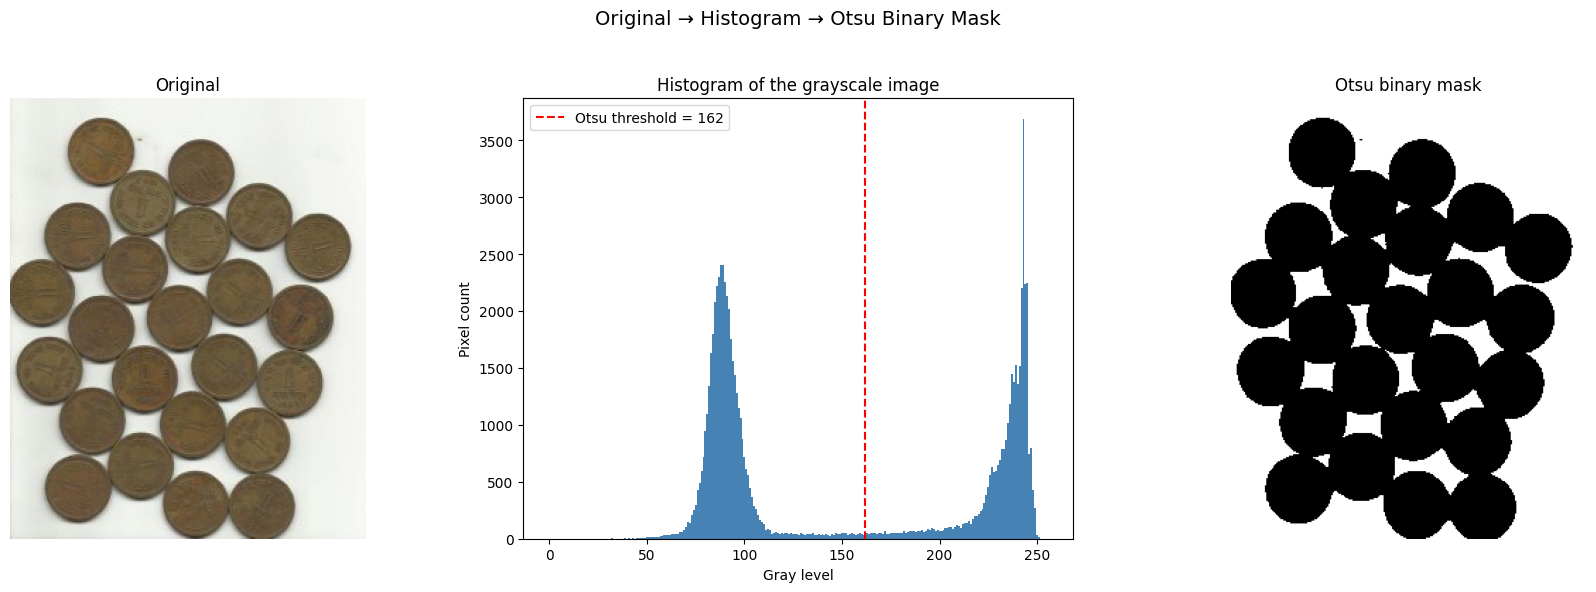

True

In [56]:
t3_fig, t3_axes = plt.subplots(1, 3, figsize=(18, 6))
t3_axes[0].imshow(cv2.cvtColor(t3_bgr, cv2.COLOR_BGR2RGB))
t3_axes[0].set_title("Original")
t3_axes[0].axis("off")

t3_axes[1].bar(range(256), t3_hist, width=1.0, color="steelblue")
t3_axes[1].axvline(t3_otsu_value, color="red", linestyle="--", label=f"Otsu threshold = {t3_otsu_value:.0f}")
t3_axes[1].set_title("Histogram of the grayscale image")
t3_axes[1].set_xlabel("Gray level")
t3_axes[1].set_ylabel("Pixel count")
t3_axes[1].legend()

t3_axes[2].imshow(t3_otsu_mask, cmap="gray")
t3_axes[2].set_title("Otsu binary mask")
t3_axes[2].axis("off")

t3_fig.suptitle("Original → Histogram → Otsu Binary Mask", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
t3_fig.savefig("outputs/task3_otsu_result.png", dpi=150, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task3_final_otsu_mask.png", t3_otsu_mask)

In [57]:
t3_variants = {
    "Baseline": t3_gray,
    "Low contrast (x0.6, +20)": cv2.convertScaleAbs(t3_gray, alpha=0.6, beta=20),
    "High contrast (x1.4, -40)": cv2.convertScaleAbs(t3_gray, alpha=1.4, beta=-40),
    "Brighter (+30)": cv2.convertScaleAbs(t3_gray, alpha=1.0, beta=30),
    "Gaussian blur 7x7": cv2.GaussianBlur(t3_gray, (7, 7), 0),
}

t3_variant_masks = {}
t3_variant_rows = []
for t3_vname, t3_vimg in t3_variants.items():
    t3_vt, t3_vmask = cv2.threshold(t3_vimg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t3_variant_masks[t3_vname] = (t3_vimg, t3_vt, t3_vmask)

for t3_vname, (t3_vimg, t3_vt, t3_vmask) in t3_variant_masks.items():
    t3_base_mask = t3_variant_masks["Baseline"][2] == 0
    t3_this_mask = t3_vmask == 0
    t3_overlap = (t3_base_mask & t3_this_mask).sum() / (t3_base_mask | t3_this_mask).sum()
    t3_variant_rows.append({
        "Variant": t3_vname,
        "Mean gray level": round(float(t3_vimg.mean()), 1),
        "Otsu threshold": float(t3_vt),
        "Coin pixels (%)": round(t3_this_mask.mean() * 100, 1),
        "Overlap with baseline mask (IoU)": round(float(t3_overlap), 3),
    })

t3_table = pd.DataFrame(t3_variant_rows)
display(t3_table)
t3_table.to_csv("outputs/task3_threshold_table.csv", index=False)

,Variant,Mean gray level,Otsu threshold,Coin pixels (%),Overlap with baseline mask (IoU)
0,Baseline,153.7,162.0,55.9,1.000
1,"Low contrast (x0.6, +20)",112.2,117.0,55.9,1.000
2,"High contrast (x1.4, -40)",160.4,167.0,55.2,0.987
3,Brighter (+30),178.6,185.0,55.5,0.994
4,Gaussian blur 7x7,153.7,163.0,56.9,0.982


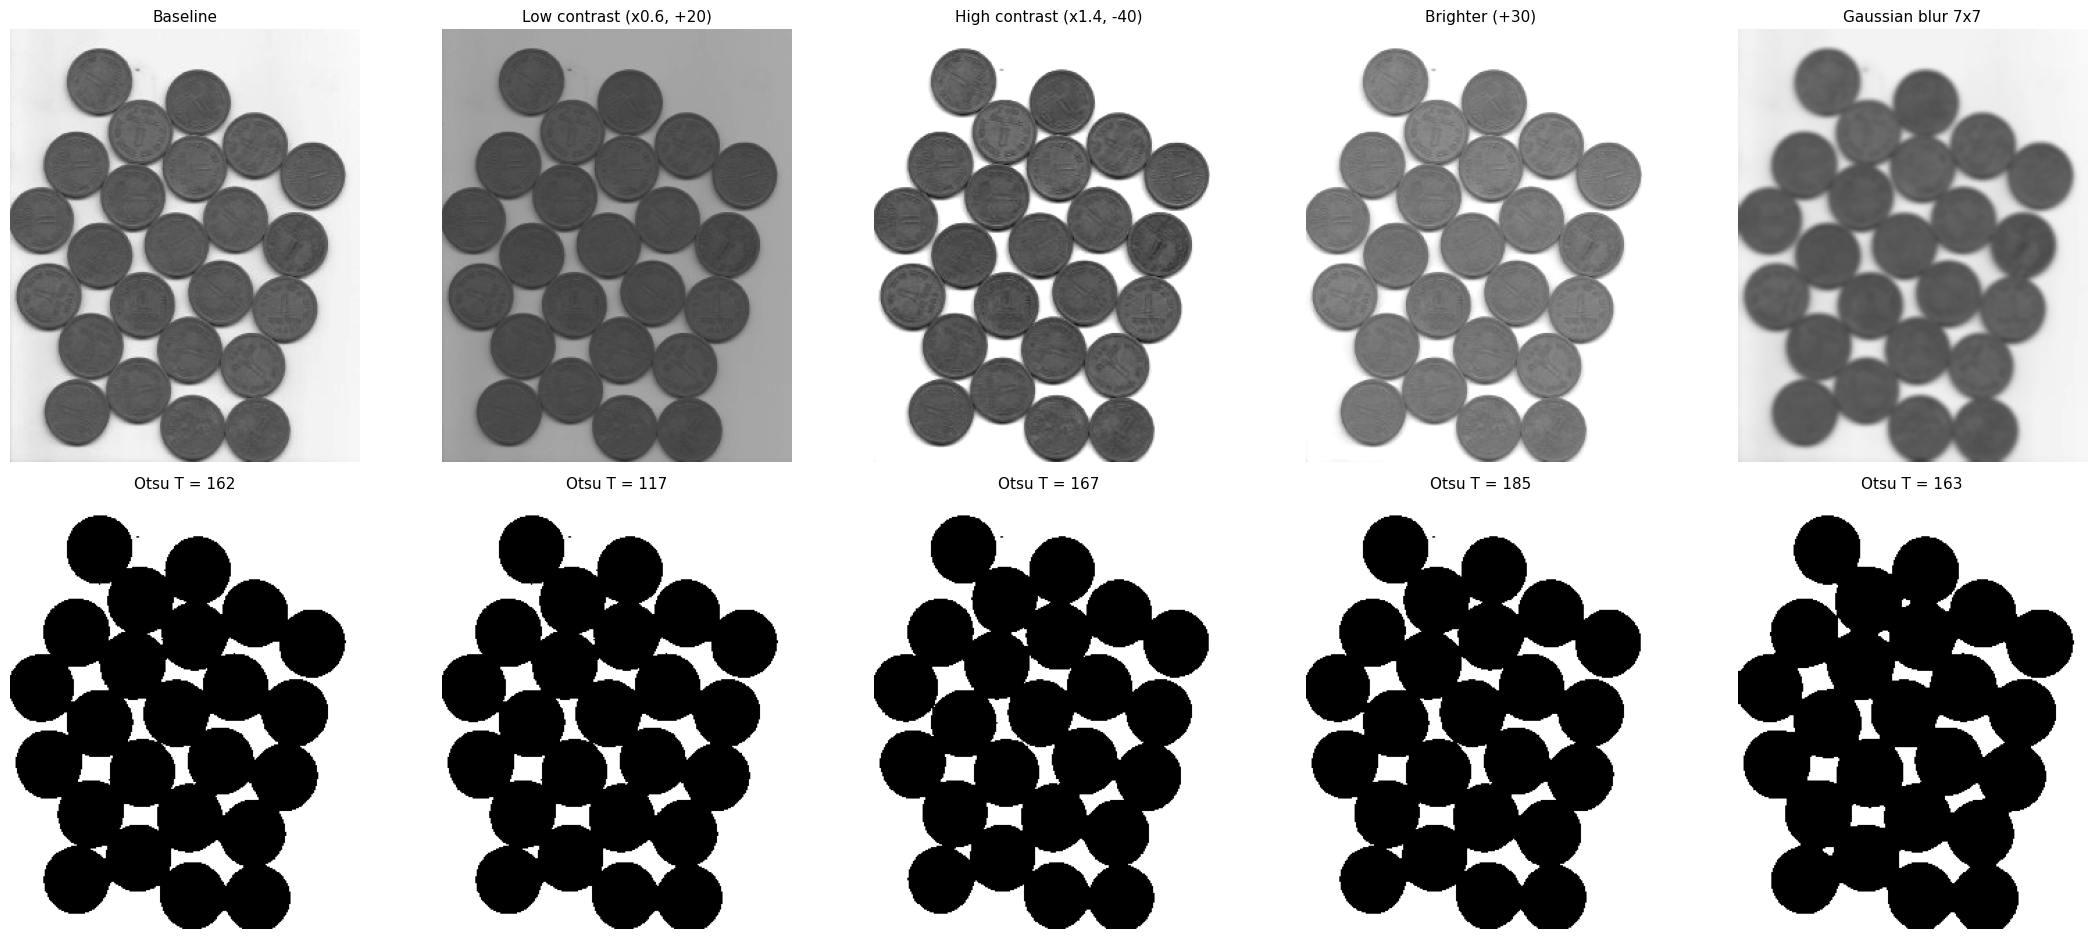

In [58]:
# Visual comparison of all variants: top row = preprocessed image, bottom row = Otsu mask
t3_fig2, t3_axes2 = plt.subplots(2, 5, figsize=(22, 9.5))
for t3_col, (t3_vname, (t3_vimg, t3_vt, t3_vmask)) in enumerate(t3_variant_masks.items()):
    t3_axes2[0, t3_col].imshow(t3_vimg, cmap="gray", vmin=0, vmax=255)
    t3_axes2[0, t3_col].set_title(t3_vname, fontsize=11)
    t3_axes2[1, t3_col].imshow(t3_vmask, cmap="gray")
    t3_axes2[1, t3_col].set_title(f"Otsu T = {t3_vt:.0f}", fontsize=11)
for t3_ax in t3_axes2.ravel():
    t3_ax.axis("off")
plt.tight_layout()
t3_fig2.savefig("outputs/task3_contrast_experiment.png", dpi=130, bbox_inches="tight")
plt.show()

### Task 3 analysis

**Histogram:** two clear peaks -- dark around 88 (coins), bright around 243 (paper) -- with an empty valley between them, exactly the two-class case Otsu is built for. It places the threshold at 162, classifying 55.9% of the image as coin.

**Across contrast variants:**

| Variant | Mean gray | Otsu T | Overlap with baseline |
|---|---|---|---|
| Baseline | 153.7 | 162 | 1.000 |
| Low contrast | 112.2 | 117 | 1.000 |
| High contrast | 160.4 | 167 | 0.987 |
| Brighter (+30) | 178.6 | 185 | 0.994 |
| Blur 7x7 | 153.7 | 163 | 0.982 |

The threshold itself moves a lot (117 to 185) as the histogram shifts, but the resulting masks stay nearly identical (>=98% overlap) -- Otsu tracks the data instead of relying on a fixed cut.

**Why is Otsu useful when the threshold isn't known beforehand?** It reads the histogram and finds the split that best separates the two pixel groups, adapting automatically as exposure drifts -- exactly what a QC line needs when lighting isn't identical from photo to photo.

**One limit:** Otsu only separates object from background, not object from object -- touching coins still merge into one blob (see Tasks 7-8).

---
## Task 4: Sorting Objects by Color

**Parameters.** OpenCV hue runs 0-179; blue sits around 100-130. The range is wide on purpose because the candies are shaded spheres -- lit top, darker edge -- and a saturation floor of 80 keeps the white background out.

| Mask | Lower (H,S,V) | Upper (H,S,V) |
|---|---|---|
| Restrictive | 108, 185, 244 | 112, 200, 255 |
| Final | 95, 80, 40 | 135, 255, 255 |

In [59]:
t4_bgr = cv2.imread("images/smarties.png")
t4_hsv = cv2.cvtColor(t4_bgr, cv2.COLOR_BGR2HSV)

t4_centres = {"Blue candy 1": (376, 81), "Blue candy 2": (346, 238), "Blue candy 3": (293, 320)}
t4_sample_rows = []
for t4_name, (t4_x, t4_y) in t4_centres.items():
    t4_window = t4_hsv[t4_y - 12:t4_y + 13, t4_x - 12:t4_x + 13].reshape(-1, 3)
    t4_p5, t4_p50, t4_p95 = np.percentile(t4_window, [5, 50, 95], axis=0)
    t4_sample_rows.append({
        "Sample": t4_name,
        "H (5-50-95%)": f"{t4_p5[0]:.0f} - {t4_p50[0]:.0f} - {t4_p95[0]:.0f}",
        "S (5-50-95%)": f"{t4_p5[1]:.0f} - {t4_p50[1]:.0f} - {t4_p95[1]:.0f}",
        "V (5-50-95%)": f"{t4_p5[2]:.0f} - {t4_p50[2]:.0f} - {t4_p95[2]:.0f}",
    })
display(pd.DataFrame(t4_sample_rows))

,Sample,H (5-50-95%),S (5-50-95%),V (5-50-95%)
0,Blue candy 1,103 - 106 - 111,190 - 200 - 209,242 - 248 - 253
1,Blue candy 2,106 - 111 - 121,182 - 191 - 202,241 - 246 - 254
2,Blue candy 3,103 - 109 - 119,183 - 193 - 207,240 - 247 - 252


In [60]:
t4_lower_tight = np.array([108, 185, 244])
t4_upper_tight = np.array([112, 200, 255])
t4_mask_tight = cv2.inRange(t4_hsv, t4_lower_tight, t4_upper_tight)

t4_lower_final = np.array([95, 80, 40])
t4_upper_final = np.array([135, 255, 255])
t4_mask_final = cv2.inRange(t4_hsv, t4_lower_final, t4_upper_final)

t4_mask_final = cv2.morphologyEx(t4_mask_final, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))

t4_extract_tight = cv2.bitwise_and(t4_bgr, t4_bgr, mask=t4_mask_tight)
t4_extract_final = cv2.bitwise_and(t4_bgr, t4_bgr, mask=t4_mask_final)

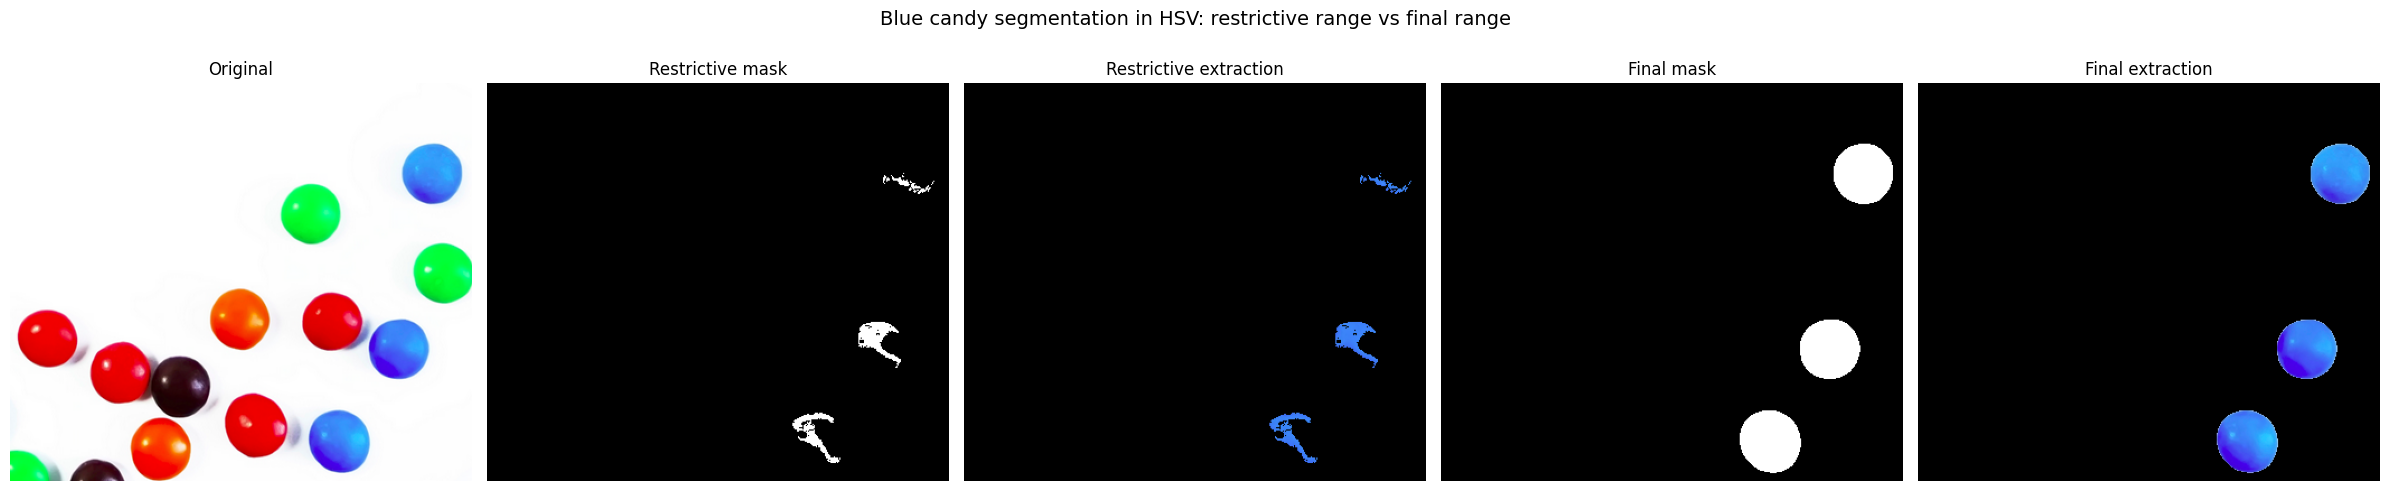

True

In [61]:
t4_fig, t4_axes = plt.subplots(1, 5, figsize=(24, 5))
t4_panels = [
    (cv2.cvtColor(t4_bgr, cv2.COLOR_BGR2RGB), "Original", None),
    (t4_mask_tight, "Restrictive mask", "gray"),
    (cv2.cvtColor(t4_extract_tight, cv2.COLOR_BGR2RGB), "Restrictive extraction", None),
    (t4_mask_final, "Final mask", "gray"),
    (cv2.cvtColor(t4_extract_final, cv2.COLOR_BGR2RGB), "Final extraction", None),
]
for t4_ax, (t4_img, t4_title, t4_cmap) in zip(t4_axes, t4_panels):
    t4_ax.imshow(t4_img, cmap=t4_cmap)
    t4_ax.set_title(t4_title)
    t4_ax.axis("off")
t4_fig.suptitle("Blue candy segmentation in HSV: restrictive range vs final range", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
t4_fig.savefig("outputs/task4_hsv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task4_final_mask.png", t4_mask_final)
cv2.imwrite("outputs/task4_final_extraction.png", t4_extract_final)

### Task 4 analysis

**Samples.** At the center of three blue candies: hue ~106-111, saturation ~190-200, value ~246-248 -- but the 5th-95th percentile spread is wider (hue 103-121 on one candy alone), showing real variation even within a single object.

**Restrictive mask.** Built to hug the center values, it only recovers a thin crescent of each candy and breaks into several stray pieces.

**Final mask.** With H 95-135, S 80-255, V 40-255, all three candies come out as complete discs, the other colors stay excluded, and a 7x7 opening cleans up a small shadow speck.

**Why the restrictive mask fails:** a candy isn't one flat color -- it's a shaded sphere, so hue, saturation and value all shift from the lit top to the shadowed edge. A range tuned to only the brightest patch rejects the rest of the same object. HSV helps because hue is fairly lighting-stable, but the bounds still need room for that shading.

---
## Task 5: Detecting the Boundary of a Manufactured Part

**Parameters.** Low threshold fixed at 10 while high goes 40, 150, 400, to isolate the effect of the high threshold alone. An extra pair (250, 400) shows what a high low-threshold does.

| Result | Low | High |
|---|---|---|
| 1 | 10 | 40 |
| 2 | 10 | 150 |
| 3 | 10 | 400 |
| Extra | 250 | 400 |

In [62]:
t5_bgr = cv2.imread("images/smarties.png")
t5_gray = cv2.cvtColor(t5_bgr, cv2.COLOR_BGR2GRAY)

t5_blur = cv2.GaussianBlur(t5_gray, (5, 5), 1.4)

t5_pairs = [(10, 40), (10, 150), (10, 400)]
t5_extra_pair = (250, 400)

t5_edges = [cv2.Canny(t5_blur, t5_low, t5_high) for t5_low, t5_high in t5_pairs]
t5_extra_edges = cv2.Canny(t5_blur, *t5_extra_pair)

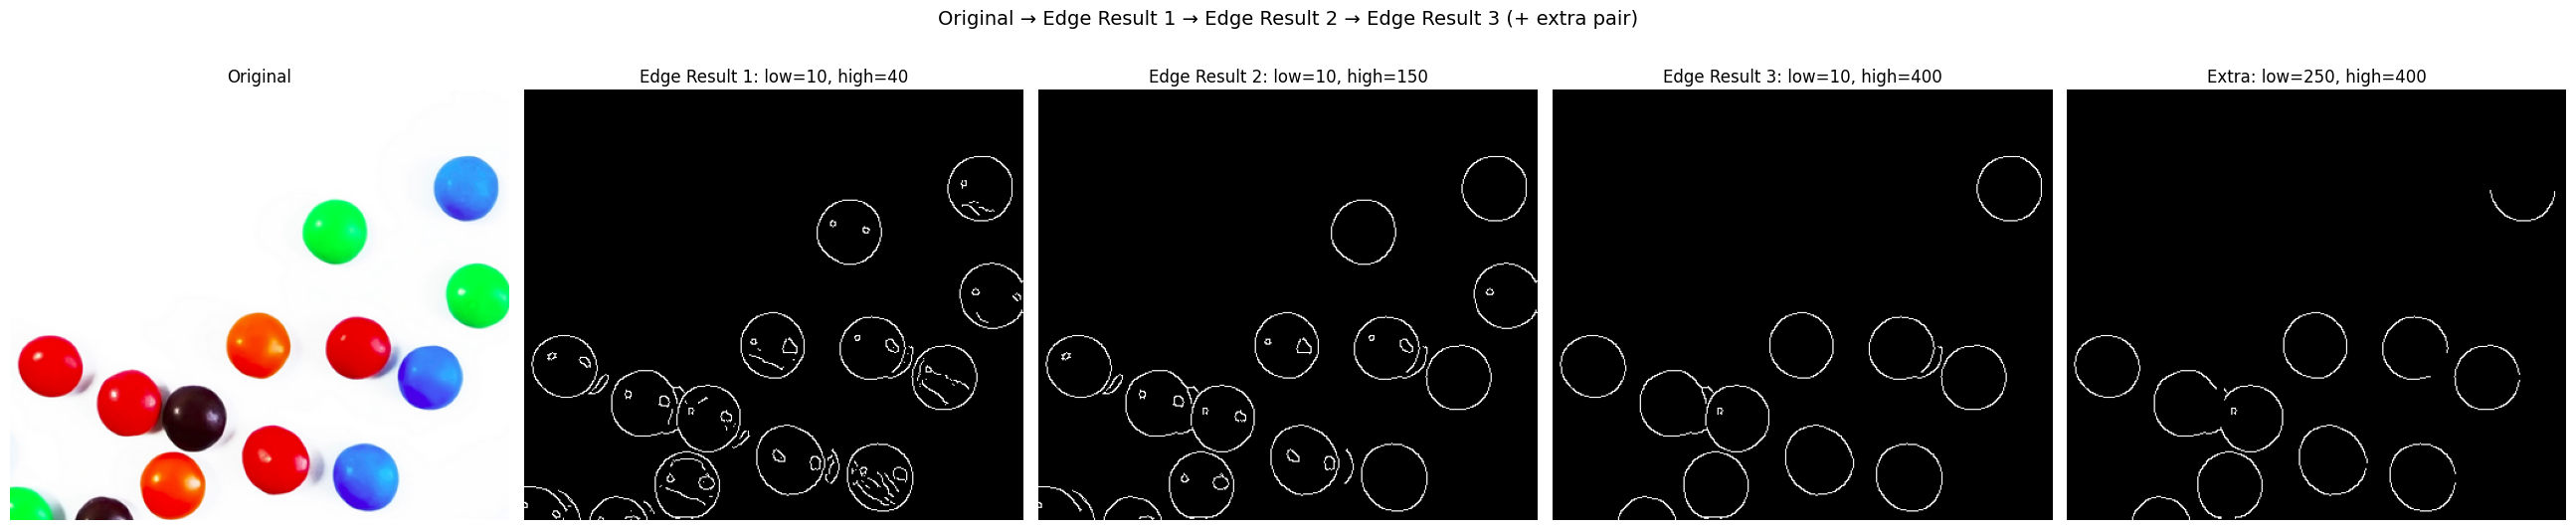

True

In [63]:
t5_fig, t5_axes = plt.subplots(1, 5, figsize=(26, 5.5))
t5_axes[0].imshow(cv2.cvtColor(t5_bgr, cv2.COLOR_BGR2RGB))
t5_axes[0].set_title("Original")
for t5_k in range(3):
    t5_axes[t5_k + 1].imshow(t5_edges[t5_k], cmap="gray")
    t5_axes[t5_k + 1].set_title(f"Edge Result {t5_k + 1}: low={t5_pairs[t5_k][0]}, high={t5_pairs[t5_k][1]}")
t5_axes[4].imshow(t5_extra_edges, cmap="gray")
t5_axes[4].set_title(f"Extra: low={t5_extra_pair[0]}, high={t5_extra_pair[1]}")
for t5_ax in t5_axes:
    t5_ax.axis("off")
t5_fig.suptitle("Original → Edge Result 1 → Edge Result 2 → Edge Result 3 (+ extra pair)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
t5_fig.savefig("outputs/task5_canny_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task5_final_edges.png", t5_edges[1])

In [64]:
t5_sat = cv2.cvtColor(t5_bgr, cv2.COLOR_BGR2HSV)[:, :, 1]
t5_candy = (t5_sat > 50).astype(np.uint8) * 255
t5_candy = cv2.morphologyEx(t5_candy, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
t5_outline = cv2.subtract(t5_candy, cv2.erode(t5_candy, np.ones((3, 3), np.uint8))) > 0

t5_rows = []
for t5_name, t5_map in [("Result 1 (10, 40)", t5_edges[0]), ("Result 2 (10, 150)", t5_edges[1]),
                        ("Result 3 (10, 400)", t5_edges[2]), ("Extra (250, 400)", t5_extra_edges)]:
    t5_near = cv2.dilate(t5_map, np.ones((5, 5), np.uint8)) > 0
    t5_outline_hit = t5_outline & t5_near
    t5_near_outline = cv2.dilate(t5_outline.astype(np.uint8), np.ones((7, 7), np.uint8)) > 0
    t5_unwanted = (t5_map > 0) & ~t5_near_outline
    t5_rows.append({
        "Result": t5_name,
        "Edge pixels": int((t5_map > 0).sum()),
        "Outline pixels found (%)": round(100 * t5_outline_hit.sum() / t5_outline.sum(), 1),
        "Missing outline (%)": round(100 - 100 * t5_outline_hit.sum() / t5_outline.sum(), 1),
        "Unwanted edge pixels": int(t5_unwanted.sum()),
    })
t5_table = pd.DataFrame(t5_rows)
display(t5_table)
t5_table.to_csv("outputs/task5_edge_table.csv", index=False)

,Result,Edge pixels,Outline pixels found (%),Missing outline (%),Unwanted edge pixels
0,"Result 1 (10, 40)",3829,99.7,0.3,1070
1,"Result 2 (10, 150)",3067,99.2,0.8,362
2,"Result 3 (10, 400)",2113,78.5,21.5,39
3,"Extra (250, 400)",1865,72.9,27.1,0


### Task 5 analysis

Outline recovery measured against the candies' saturation-based outline (a rough but useful ruler):

| Result | Edge px | Outline found | Missing | Unwanted px |
|---|---|---|---|---|
| 1 (10,40) | 3829 | 99.7% | 0.3% | 1070 |
| 2 (10,150) | 3067 | 99.2% | 0.8% | 362 |
| 3 (10,400) | 2113 | 78.5% | 21.5% | 39 |
| Extra (250,400) | 1865 | 72.9% | 27.1% | 0 |

**Strong edges:** red, dark brown and blue candy outlines -- high contrast against white, survive every pair.
**Weak edges:** green candy outlines and soft shadows -- close in brightness to the background, kept only via hysteresis when connected to a strong edge.
**Missing edges:** the green candies vanish entirely in Results 3 and Extra once the high threshold exceeds their gradient strength.
**Unwanted edges:** mostly shiny highlights and shadow arcs, worst in Result 1, shrinking as thresholds rise.

**Effect of the two thresholds:** the high threshold decides which edges are trusted as real (raising it drops weak-but-real edges along with clutter); the low threshold decides how far an edge may extend from a strong pixel (raising it breaks chains into dashes, lowering it lets more noise through). Result 2 (10, 150) is the best balance -- 99.2% outline recovery with about a third of Result 1's noise -- and is saved as the final output.

---
## Task 6: Segmenting a Region Inside a Medical Image

**Parameters**

| Parameter | Value | Why |
|---|---|---|
| Smoothing | 3x3 Gaussian | Reduces noise without erasing the region |
| Reference intensity | Mean of a 5x5 patch around the seed | One noisy pixel shouldn't decide everything |
| Thresholds | 10, 20, 35 | Tight, medium, loose |
| Seed A | (149, 219) | Inside the bright mass |
| Seed B | (294, 194) | Ordinary tissue, right hemisphere |

In [65]:
t6_mri = cv2.imread("images/biotechnology-Input-image-12-12-118-g007.png", cv2.IMREAD_GRAYSCALE)

t6_smooth = cv2.GaussianBlur(t6_mri, (3, 3), 0)
print("Cropped MRI size:", t6_mri.shape)

def t6_region_grow(t6_img, t6_seed, t6_threshold, t6_patch=2):
    t6_h, t6_w = t6_img.shape
    t6_x0, t6_y0 = t6_seed
    t6_ref = t6_img[max(t6_y0 - t6_patch, 0):t6_y0 + t6_patch + 1,
                    max(t6_x0 - t6_patch, 0):t6_x0 + t6_patch + 1].mean()
    t6_out = np.zeros((t6_h, t6_w), np.uint8)
    t6_out[t6_y0, t6_x0] = 255
    t6_queue = deque([(t6_x0, t6_y0)])
    while t6_queue:
        t6_cx, t6_cy = t6_queue.popleft()
        for t6_dx in (-1, 0, 1):
            for t6_dy in (-1, 0, 1):
                t6_nx, t6_ny = t6_cx + t6_dx, t6_cy + t6_dy
                if 0 <= t6_nx < t6_w and 0 <= t6_ny < t6_h and t6_out[t6_ny, t6_nx] == 0:
                    if abs(float(t6_img[t6_ny, t6_nx]) - t6_ref) <= t6_threshold:
                        t6_out[t6_ny, t6_nx] = 255
                        t6_queue.append((t6_nx, t6_ny))
    return t6_out, t6_ref

Cropped MRI size: (371, 442)


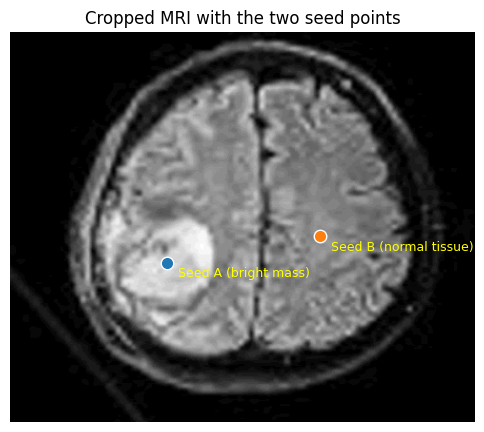

,Seed,"Seed position (x, y)",Seed reference intensity,Threshold,Region area (px),Share of image (%)
0,Seed A (bright mass),"(149, 219)",209.0,10,1888,1.2
1,Seed A (bright mass),"(149, 219)",209.0,20,3261,2.0
2,Seed A (bright mass),"(149, 219)",209.0,35,4389,2.7
3,Seed B (normal tissue),"(294, 194)",157.7,10,354,0.2
4,Seed B (normal tissue),"(294, 194)",157.7,20,2553,1.6
5,Seed B (normal tissue),"(294, 194)",157.7,35,38917,23.7


In [66]:
t6_seeds = {"Seed A (bright mass)": (149, 219), "Seed B (normal tissue)": (294, 194)}
t6_thresholds = [10, 20, 35]

t6_fig0, t6_ax0 = plt.subplots(figsize=(6, 6))
t6_ax0.imshow(t6_mri, cmap="gray")
for t6_label, (t6_sx, t6_sy) in t6_seeds.items():
    t6_ax0.plot(t6_sx, t6_sy, "o", markersize=9, markeredgecolor="white")
    t6_ax0.annotate(t6_label, (t6_sx, t6_sy), color="yellow", xytext=(8, -10), textcoords="offset points", fontsize=9)
t6_ax0.set_title("Cropped MRI with the two seed points")
t6_ax0.axis("off")
plt.show()

t6_masks = {}
t6_rows = []
for t6_label, t6_seed in t6_seeds.items():
    for t6_thr in t6_thresholds:
        t6_mask, t6_ref = t6_region_grow(t6_smooth, t6_seed, t6_thr)
        t6_masks[(t6_label, t6_thr)] = t6_mask
        t6_rows.append({
            "Seed": t6_label, "Seed position (x, y)": str(t6_seed), "Seed reference intensity": round(float(t6_ref), 1),
            "Threshold": t6_thr, "Region area (px)": int((t6_mask > 0).sum()),
            "Share of image (%)": round(100 * (t6_mask > 0).mean(), 1),
        })
t6_table = pd.DataFrame(t6_rows)
display(t6_table)
t6_table.to_csv("outputs/task6_region_table.csv", index=False)

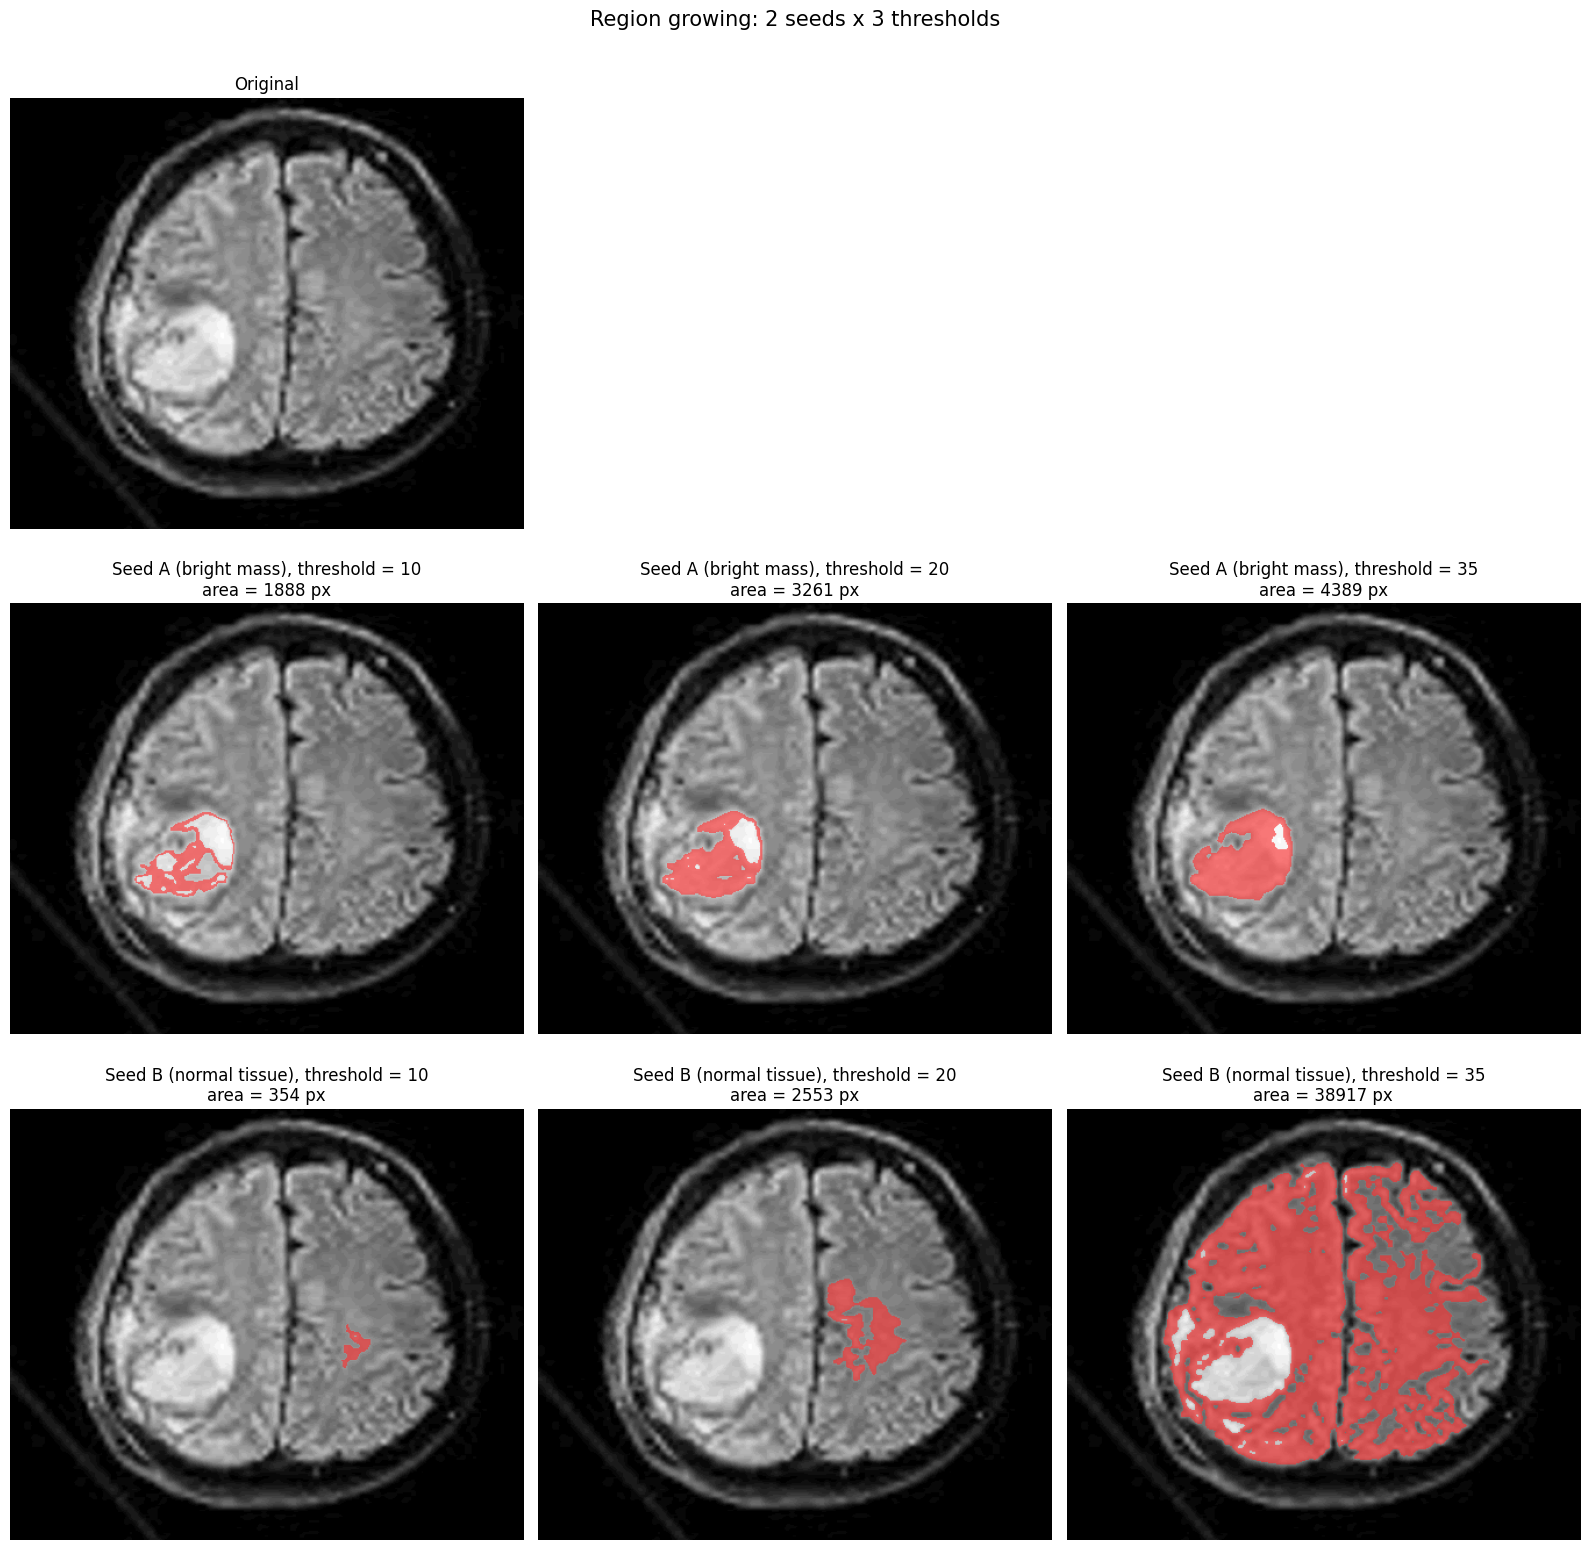

True

In [67]:
t6_fig, t6_axes = plt.subplots(3, 3, figsize=(16, 16))
t6_axes[0, 0].imshow(t6_mri, cmap="gray")
t6_axes[0, 0].set_title("Original")
t6_axes[0, 1].axis("off")
t6_axes[0, 2].axis("off")
for t6_r, t6_label in enumerate(t6_seeds):
    for t6_c, t6_thr in enumerate(t6_thresholds):
        t6_ax = t6_axes[t6_r + 1, t6_c]
        t6_m = t6_masks[(t6_label, t6_thr)]
        t6_rgb = cv2.cvtColor(t6_mri, cv2.COLOR_GRAY2RGB)
        t6_rgb[t6_m > 0] = (0.4 * t6_rgb[t6_m > 0] + 0.6 * np.array([255, 40, 40])).astype(np.uint8)
        t6_ax.imshow(t6_rgb)
        t6_ax.set_title(f"{t6_label}, threshold = {t6_thr}\narea = {int((t6_m > 0).sum())} px")
for t6_ax in t6_axes.ravel():
    t6_ax.axis("off")
t6_fig.suptitle("Region growing: 2 seeds x 3 thresholds", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
t6_fig.savefig("outputs/task6_region_growing_grid.png", dpi=120, bbox_inches="tight")
plt.show()

cv2.imwrite("outputs/task6_final_mask_seedA_thr35.png", t6_masks[("Seed A (bright mass)", 35)])
cv2.imwrite("outputs/task6_final_mask_seedB_thr20.png", t6_masks[("Seed B (normal tissue)", 20)])

### Task 6 analysis

| Seed | Ref. intensity | Threshold | Area (px) | Share |
|---|---|---|---|---|
| A (bright mass) | 209.0 | 10 | 1888 | 1.2% |
| A (bright mass) | 209.0 | 20 | 3261 | 2.0% |
| A (bright mass) | 209.0 | 35 | 4389 | 2.7% |
| B (normal tissue) | 157.7 | 10 | 354 | 0.2% |
| B (normal tissue) | 157.7 | 20 | 2553 | 1.6% |
| B (normal tissue) | 157.7 | 35 | 38917 | 23.7% |

**Effect of threshold.** Larger threshold -> larger region, for both seeds. Seed A grows steadily and stays inside the bright mass even at 35. Seed B is far more sensitive: at 35 its acceptance window (roughly 123-193) now spans most normal tissue, and since tissue is well connected through the brain's folds, the region leaks across both hemispheres to 23.7% of the whole image.

**Why can changing the seed point significantly change the result?** The seed sets the reference intensity every other pixel is judged against. Seed A's reference (209) is far from normal tissue (157), so tissue can never join and the region stays contained. Seed B's reference (157) sits right in the typical tissue range, so its window easily spans the surrounding brain and the region can spread a long way. Region growing is only as good as the seed and threshold chosen for the target's intensity range.

---
## Task 7: Separating Touching Coins in an Automated Counting System

**Parameters**

| Stage | Setting | Why |
|---|---|---|
| Preprocessing | 5x5 Gaussian blur | Removes coin-face texture |
| Thresholding | Otsu (inverted) | Automatic; histogram is clearly two-peaked (Task 3) |
| Noise removal | 3x3 opening, 2 iterations | Clears specks and thin bridges |
| Sure background | Dilation, 3 iterations | Anything outside this is definitely background |
| Distance transform | L2, mask size 5 | Round peak at the middle of each coin |
| Sure foreground | 70% of max distance | Keeps only each coin's core, so touching coins get separate markers |

In [68]:
t7_bgr = cv2.imread("images/water_coins.jpg")

# Stage 1:
t7_gray = cv2.cvtColor(t7_bgr, cv2.COLOR_BGR2GRAY)
t7_blur = cv2.GaussianBlur(t7_gray, (5, 5), 0)

# Stage 2:
t7_otsu_value, t7_thresh = cv2.threshold(t7_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Stage 3:
t7_kernel = np.ones((3, 3), np.uint8)
t7_opening = cv2.morphologyEx(t7_thresh, cv2.MORPH_OPEN, t7_kernel, iterations=2)

# Stage 4:
t7_sure_bg = cv2.dilate(t7_opening, t7_kernel, iterations=3)

# Stage 5:
t7_dist = cv2.distanceTransform(t7_opening, cv2.DIST_L2, 5)

# Stage 6:
t7_dist_ratio = 0.7
t7_unused, t7_sure_fg = cv2.threshold(t7_dist, t7_dist_ratio * t7_dist.max(), 255, 0)
t7_sure_fg = np.uint8(t7_sure_fg)

# Stage 7:
t7_unknown = cv2.subtract(t7_sure_bg, t7_sure_fg)

# Stage 8:
t7_num_labels, t7_core_labels = cv2.connectedComponents(t7_sure_fg)
t7_markers = t7_core_labels + 1
t7_markers[t7_unknown == 255] = 0

# Stage 9:
t7_markers = cv2.watershed(t7_bgr.copy(), t7_markers.astype(np.int32))

# Stage 10:
t7_boundary_mask = t7_markers == -1
t7_boundary_mask[0, :] = t7_boundary_mask[-1, :] = False
t7_boundary_mask[:, 0] = t7_boundary_mask[:, -1] = False
t7_final = t7_bgr.copy()
t7_final[t7_boundary_mask] = (0, 0, 255)

t7_coins_threshold_only = cv2.connectedComponents(t7_thresh)[0] - 1
t7_coins_watershed = len([t7_l for t7_l in np.unique(t7_markers) if t7_l > 1])
print("Otsu threshold:", t7_otsu_value)
print("Connected regions after simple thresholding:", t7_coins_threshold_only)
print("Sure foreground markers:", t7_num_labels - 1)
print("Coins found by watershed:", t7_coins_watershed)

Otsu threshold: 162.0
Connected regions after simple thresholding: 1
Sure foreground markers: 24
Coins found by watershed: 24


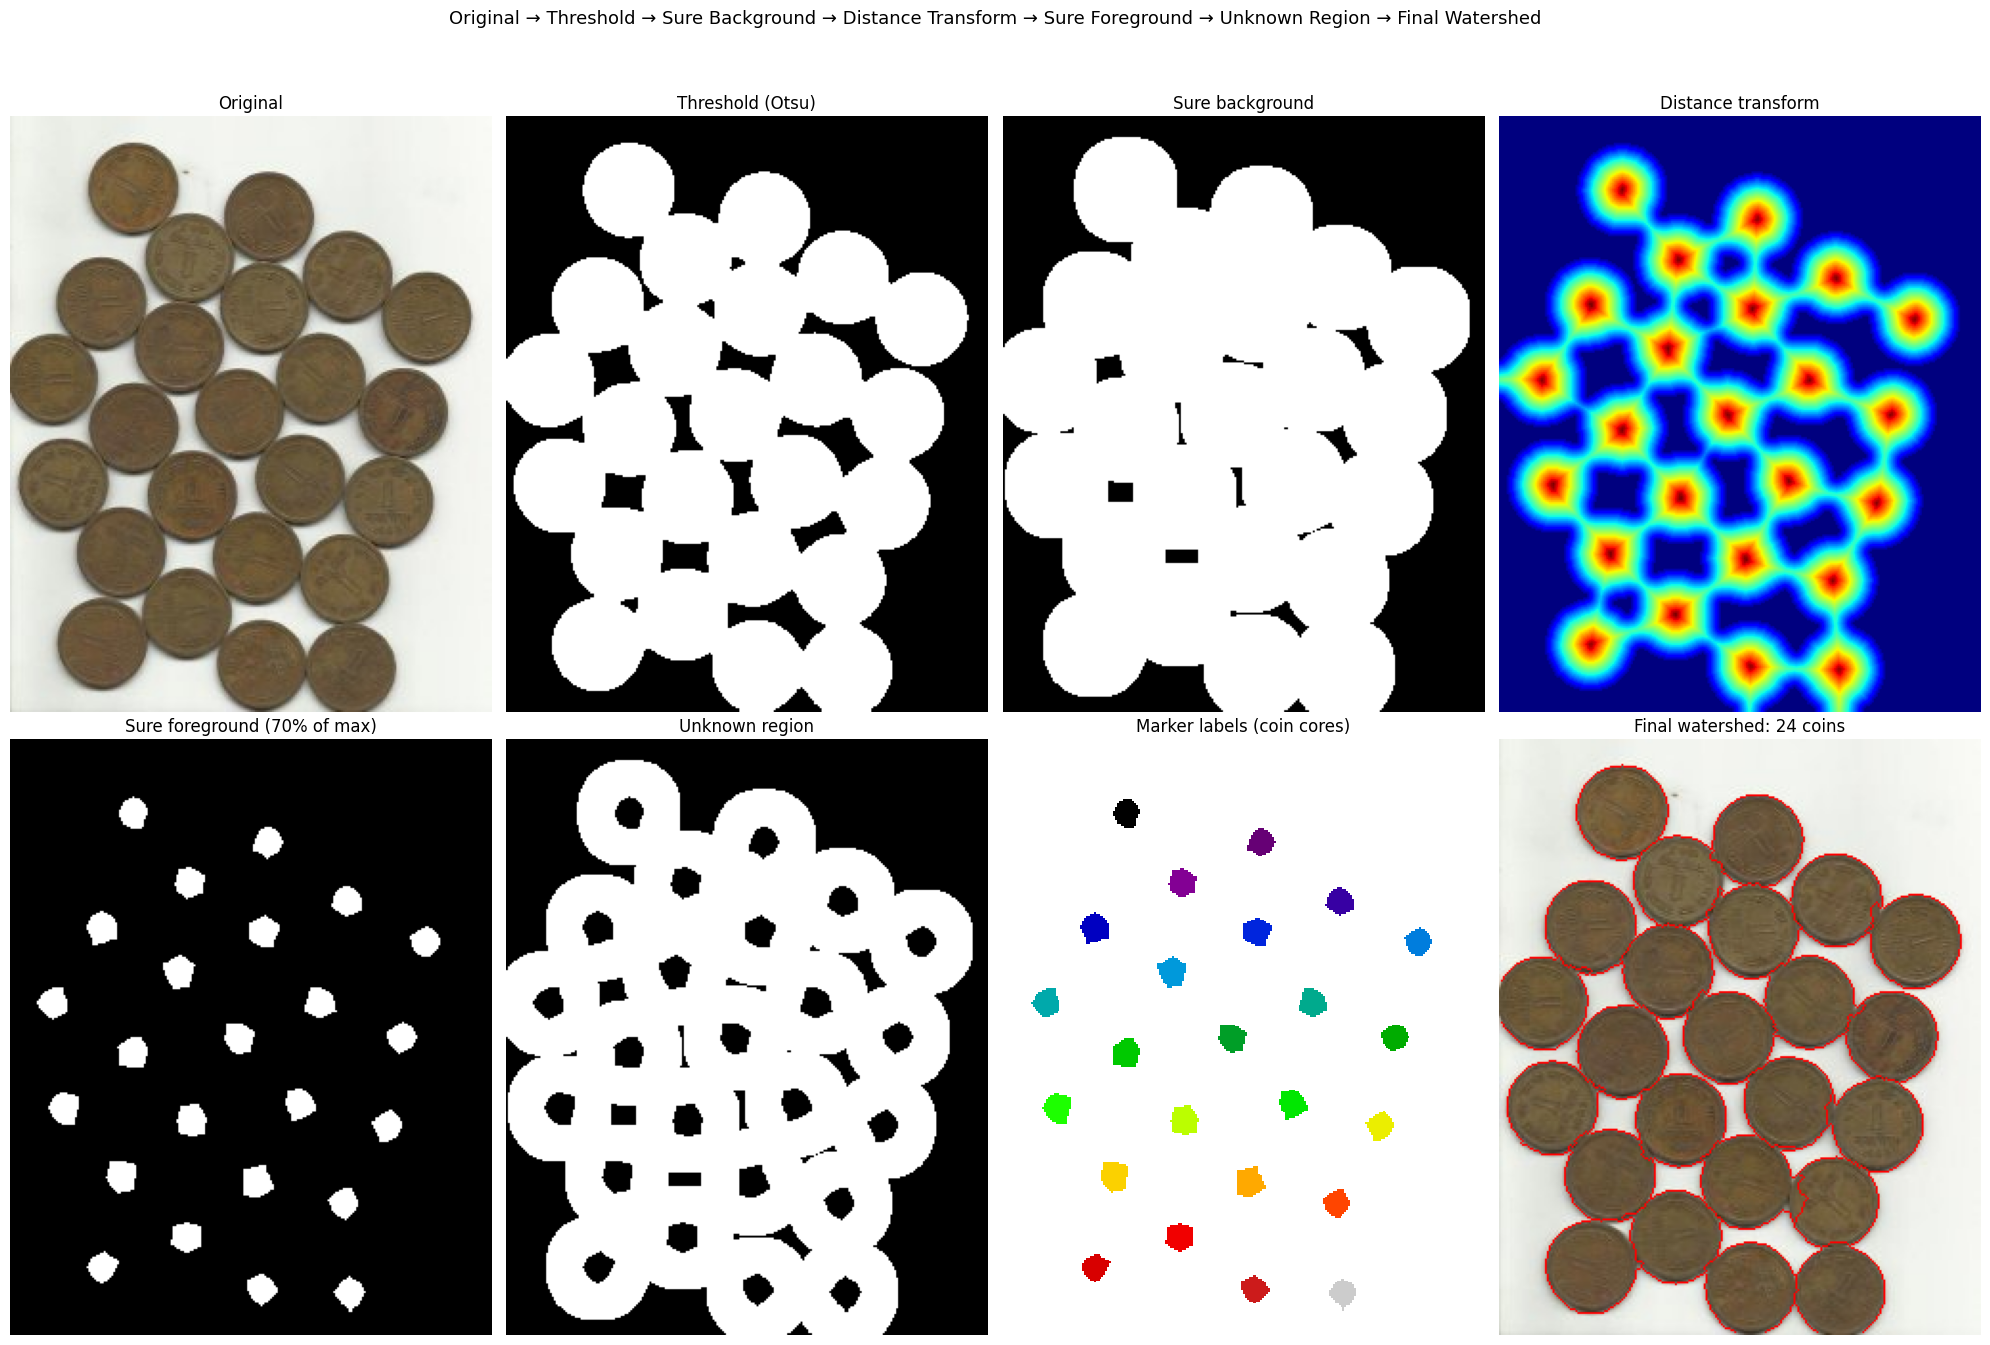

True

In [69]:
t7_panels = [
    (cv2.cvtColor(t7_bgr, cv2.COLOR_BGR2RGB), "Original", None),
    (t7_thresh, "Threshold (Otsu)", "gray"),
    (t7_sure_bg, "Sure background", "gray"),
    (t7_dist, "Distance transform", "jet"),
    (t7_sure_fg, f"Sure foreground ({int(t7_dist_ratio * 100)}% of max)", "gray"),
    (t7_unknown, "Unknown region", "gray"),
    (np.ma.masked_equal(t7_core_labels, 0), "Marker labels (coin cores)", "nipy_spectral"),
    (cv2.cvtColor(t7_final, cv2.COLOR_BGR2RGB), f"Final watershed: {t7_coins_watershed} coins", None),
]
t7_fig, t7_axes = plt.subplots(2, 4, figsize=(20, 14))
for t7_ax, (t7_img, t7_title, t7_cmap) in zip(t7_axes.ravel(), t7_panels):
    t7_ax.imshow(t7_img, cmap=t7_cmap)
    t7_ax.set_title(t7_title, fontsize=12)
    t7_ax.axis("off")
t7_fig.suptitle("Original → Threshold → Sure Background → Distance Transform → Sure Foreground → Unknown Region → Final Watershed",
                fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
t7_fig.savefig("outputs/task7_watershed_pipeline.png", dpi=120, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task7_final_watershed.png", t7_final)

### Task 7 analysis

**Result.** Simple Otsu thresholding gives 1 connected region for the whole pile. The distance transform shows one peak per coin; the 70% cut leaves 24 separate cores (sure foreground), and watershed grows each marker until it meets its neighbour. Final count: 24 coins.

**Visual check.** The red boundary lines run along the contact points between touching coins and the outer edge of each coin -- every touching pair in the thresholded mask is now separated (one stray internal mark on a coin doesn't split it).

**Why it works.** A touching pair forms a neck in the mask. The distance transform is low at the neck and high at each coin's centre, so thresholding the distance map drops the necks while each coin keeps its own core -- giving watershed exactly the right number of starting markers.

---
## Task 8: Tuning Watershed for Difficult Object Separation

In [70]:
t8_bgr = cv2.imread("images/water_coins.jpg")
t8_gray = cv2.cvtColor(t8_bgr, cv2.COLOR_BGR2GRAY)
t8_blur = cv2.GaussianBlur(t8_gray, (5, 5), 0)

t8_unused, t8_thresh = cv2.threshold(t8_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
t8_kernel = np.ones((3, 3), np.uint8)
t8_opening = cv2.morphologyEx(t8_thresh, cv2.MORPH_OPEN, t8_kernel, iterations=2)
t8_sure_bg = cv2.dilate(t8_opening, t8_kernel, iterations=3)
t8_dist = cv2.distanceTransform(t8_opening, cv2.DIST_L2, 5)
print("Largest distance value (roughly the radius of the biggest coin):", round(float(t8_dist.max()), 1), "px")

def t8_watershed(t8_ratio):
    t8_unused2, t8_fg = cv2.threshold(t8_dist, t8_ratio * t8_dist.max(), 255, 0)
    t8_fg = np.uint8(t8_fg)
    t8_unk = cv2.subtract(t8_sure_bg, t8_fg)
    t8_n, t8_mk = cv2.connectedComponents(t8_fg)
    t8_mk = t8_mk + 1
    t8_mk[t8_unk == 255] = 0
    t8_mk = cv2.watershed(t8_bgr.copy(), t8_mk.astype(np.int32))
    t8_edge = t8_mk == -1
    t8_edge[0, :] = t8_edge[-1, :] = False
    t8_edge[:, 0] = t8_edge[:, -1] = False
    t8_vis = t8_bgr.copy()
    t8_vis[t8_edge] = (0, 0, 255)
    t8_regions = len([t8_l for t8_l in np.unique(t8_mk) if t8_l > 1])
    return t8_n - 1, t8_regions, t8_vis, t8_fg

Largest distance value (roughly the radius of the biggest coin): 24.0 px


In [71]:
t8_ratios = [0.30, 0.40, 0.50, 0.70, 0.90, 0.99]
t8_true_count = 24

t8_results = []
for t8_r in t8_ratios:
    t8_markers_found, t8_regions_found, t8_vis_img, t8_fg_img = t8_watershed(t8_r)
    t8_results.append((t8_r, t8_markers_found, t8_regions_found, t8_vis_img, t8_fg_img))

def t8_describe(t8_markers_found, t8_regions_found):
    if t8_regions_found < t8_true_count and t8_markers_found < t8_true_count and t8_markers_found <= 0.5 * t8_true_count:
        return f"Under-segmented: coins stay merged into {t8_regions_found} large regions"
    if t8_regions_found < t8_true_count:
        return f"{t8_true_count - t8_regions_found} coins lost their marker and were swallowed by neighbours"
    if t8_regions_found == t8_true_count:
        return "All coins separated, one region per coin"
    return f"Over-segmented: {t8_regions_found - t8_true_count} extra regions"

t8_rows = []
for t8_idx, (t8_r, t8_m, t8_g, t8_v, t8_f) in enumerate(t8_results, start=1):
    t8_rows.append({
        "Experiment": t8_idx,
        "Distance Threshold": f"{t8_r:.2f} x max = {t8_r * t8_dist.max():.1f} px",
        "Foreground (markers)": t8_m,
        "Regions": t8_g,
        "Observed Result": t8_describe(t8_m, t8_g),
    })
t8_table = pd.DataFrame(t8_rows)
display(t8_table)
t8_table.to_csv("outputs/task8_experiment_table.csv", index=False)

,Experiment,Distance Threshold,Foreground (markers),Regions,Observed Result
0,1,0.30 x max = 7.2 px,1,1,Under-segmented: coins stay merged into 1 larg...
1,2,0.40 x max = 9.6 px,7,7,Under-segmented: coins stay merged into 7 larg...
2,3,0.50 x max = 12.0 px,24,24,"All coins separated, one region per coin"
3,4,0.70 x max = 16.8 px,24,24,"All coins separated, one region per coin"
4,5,0.90 x max = 21.6 px,24,24,"All coins separated, one region per coin"
5,6,0.99 x max = 23.8 px,20,20,4 coins lost their marker and were swallowed b...


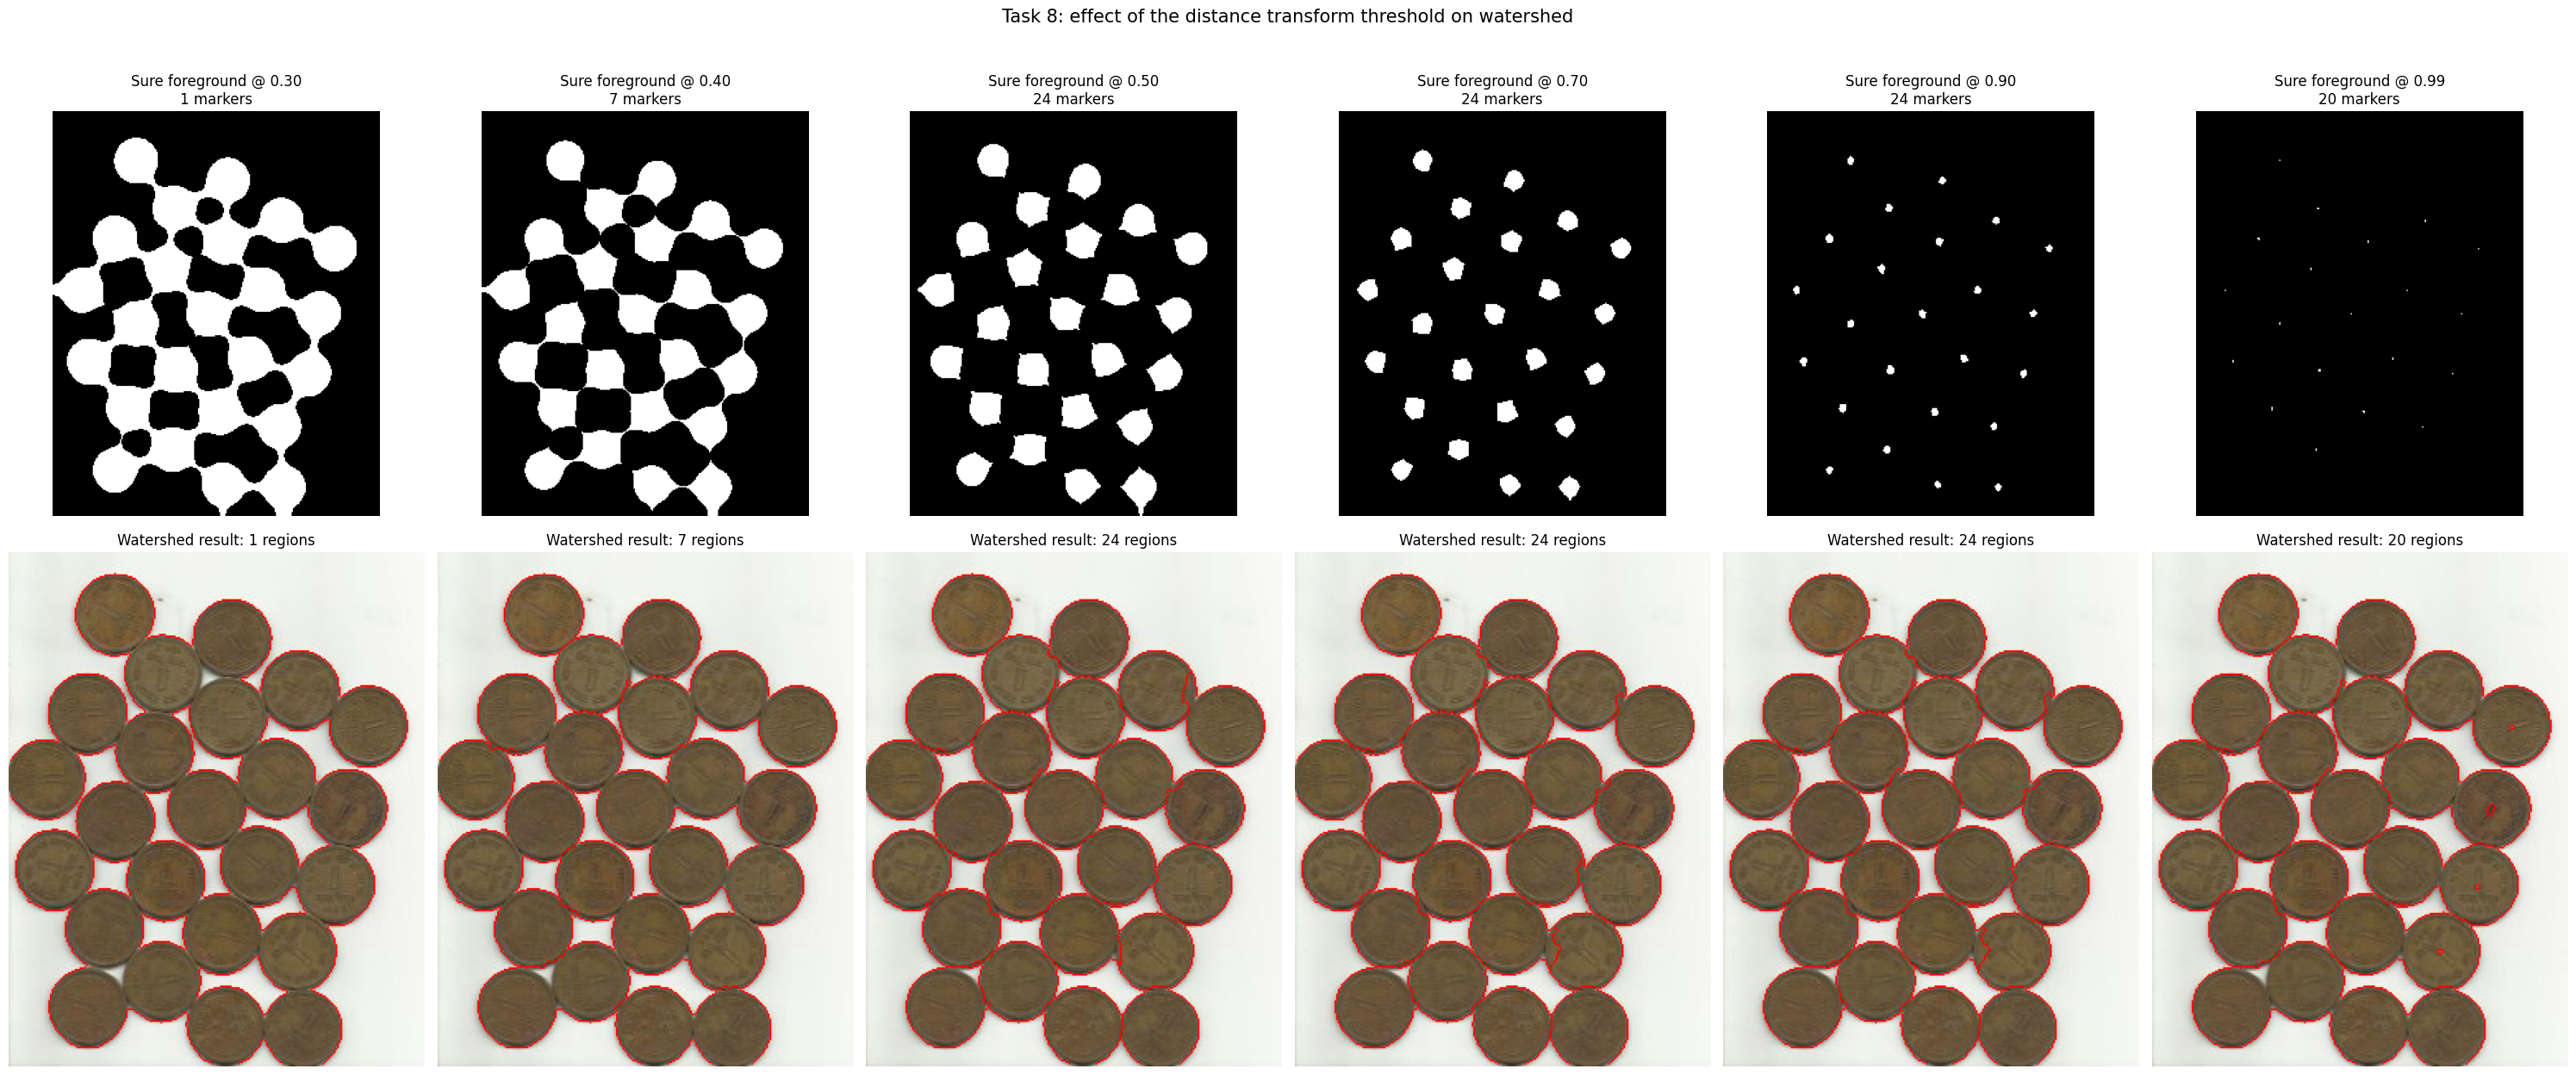

True

In [72]:
t8_fig, t8_axes = plt.subplots(2, 6, figsize=(30, 13), gridspec_kw={"height_ratios": [1, 1.4]})
for t8_col, (t8_r, t8_m, t8_g, t8_v, t8_f) in enumerate(t8_results):
    t8_axes[0, t8_col].imshow(t8_f, cmap="gray")
    t8_axes[0, t8_col].set_title(f"Sure foreground @ {t8_r:.2f}\n{t8_m} markers", fontsize=12)
    t8_axes[1, t8_col].imshow(cv2.cvtColor(t8_v, cv2.COLOR_BGR2RGB))
    t8_axes[1, t8_col].set_title(f"Watershed result: {t8_g} regions", fontsize=12)
for t8_ax in t8_axes.ravel():
    t8_ax.axis("off")
t8_fig.suptitle("Task 8: effect of the distance transform threshold on watershed", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.5)
t8_fig.savefig("outputs/task8_threshold_experiments.png", dpi=110, bbox_inches="tight")
plt.show()

t8_best = [t8_item for t8_item in t8_results if abs(t8_item[0] - 0.70) < 1e-9][0]
cv2.imwrite("outputs/task8_final_best_result.png", t8_best[3])

In [73]:
t8_scan = []
for t8_r in np.arange(0.10, 1.00, 0.05):
    t8_m, t8_g, t8_skip1, t8_skip2 = t8_watershed(float(t8_r))
    t8_scan.append((round(float(t8_r), 2), t8_m, t8_g))
t8_scan_table = pd.DataFrame(t8_scan, columns=["Ratio", "Foreground markers", "Regions"])
t8_scan_table["Matches true count"] = t8_scan_table["Regions"] == t8_true_count
display(t8_scan_table.T)

t8_good = t8_scan_table[t8_scan_table["Matches true count"]]["Ratio"]
print(f"Ratios that recover all {t8_true_count} coins: {t8_good.min()} to {t8_good.max()}")

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
Ratio,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95
Foreground markers,1,1,1,1,1,2,7,24,24,24,24,24,24,24,24,24,24,24
Regions,1,1,1,1,1,2,7,24,24,24,24,24,24,24,24,24,24,24
Matches true count,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True


Ratios that recover all 24 coins: 0.45 to 0.95


### Task 8 analysis

| Exp. | Distance threshold | Markers | Regions | Result |
|---|---|---|---|---|
| 1 | 0.30xmax = 7.2px | 1 | 1 | Still one merged region |
| 2 | 0.40xmax = 9.6px | 7 | 7 | Several coins stay merged in groups |
| 3 | 0.50xmax = 12.0px | 24 | 24 | All coins separated |
| 4 | 0.70xmax = 16.8px | 24 | 24 | All separated, cleanest markers |
| 5 | 0.90xmax = 21.6px | 24 | 24 | All separated, markers tiny |
| 6 | 0.99xmax = 23.8px | 20 | 20 | 4 coins lose their marker, merge into neighbours |

A finer scan (step 0.05) shows every ratio from 0.45 to 0.95 recovers all 24 coins.

**Reading the lines.** The red boundary only marks where a region meets the background or another region -- in experiments 1-2 the coins look outlined from outside, but the label maps show them glued into 1 or 7 blobs, with no line between touching coins. Region count is the reliable indicator, not the outline alone.

**Best range:** about 0.5-0.8 of the max distance; 0.70 is used, sitting comfortably in the middle. Saved as `outputs/task8_final_best_result.png`.

**Failure modes.** Too low: the sure foreground still includes the necks, so neighbours share a marker and merge. Too high: only the biggest coins' very centre survives -- smaller coins get no marker at all and a neighbour swallows their area (experiment 6).

**Over-splitting.** Not observed here -- these coins are round with a single distance peak each. It would show up on elongated/lumpy shapes with two peaks, where a smoother distance map would help.

---
## Task 9: Segmenting an Image Using K-Means

**Parameters**

| Parameter | Value | Why |
|---|---|---|
| Features | B, G, R per pixel | Task asks for clustering by color similarity |
| Stop criteria | 20 iterations or movement < 1.0 | Fast and sufficient for this image size |
| Attempts | 10 | Keeps the best of 10 runs (K-Means depends on its start) |
| Init | `KMEANS_PP_CENTERS` | Spreads starting centers for more stable results |
| Seed | 42 | Reproducible run |

In [74]:
t9_bgr = cv2.imread("images/dog.jpeg")
t9_height, t9_width = t9_bgr.shape[:2]

t9_pixels = t9_bgr.reshape(-1, 3).astype(np.float32)
print("Image:", t9_bgr.shape, "-> pixel matrix:", t9_pixels.shape, t9_pixels.dtype)

t9_criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
t9_attempts = 10

t9_k_values = [2, 4, 6]
t9_segmented = {}
t9_centers = {}
t9_labels = {}
t9_compactness = {}
for t9_k in t9_k_values:
    cv2.setRNGSeed(42)
    t9_comp, t9_lab, t9_cen = cv2.kmeans(t9_pixels, t9_k, None, t9_criteria, t9_attempts, cv2.KMEANS_PP_CENTERS)
    t9_centers[t9_k] = np.uint8(t9_cen)
    t9_labels[t9_k] = t9_lab.flatten()
    t9_compactness[t9_k] = t9_comp
    t9_segmented[t9_k] = t9_centers[t9_k][t9_labels[t9_k]].reshape(t9_bgr.shape)

Image: (350, 233, 3) -> pixel matrix: (81550, 3) float32


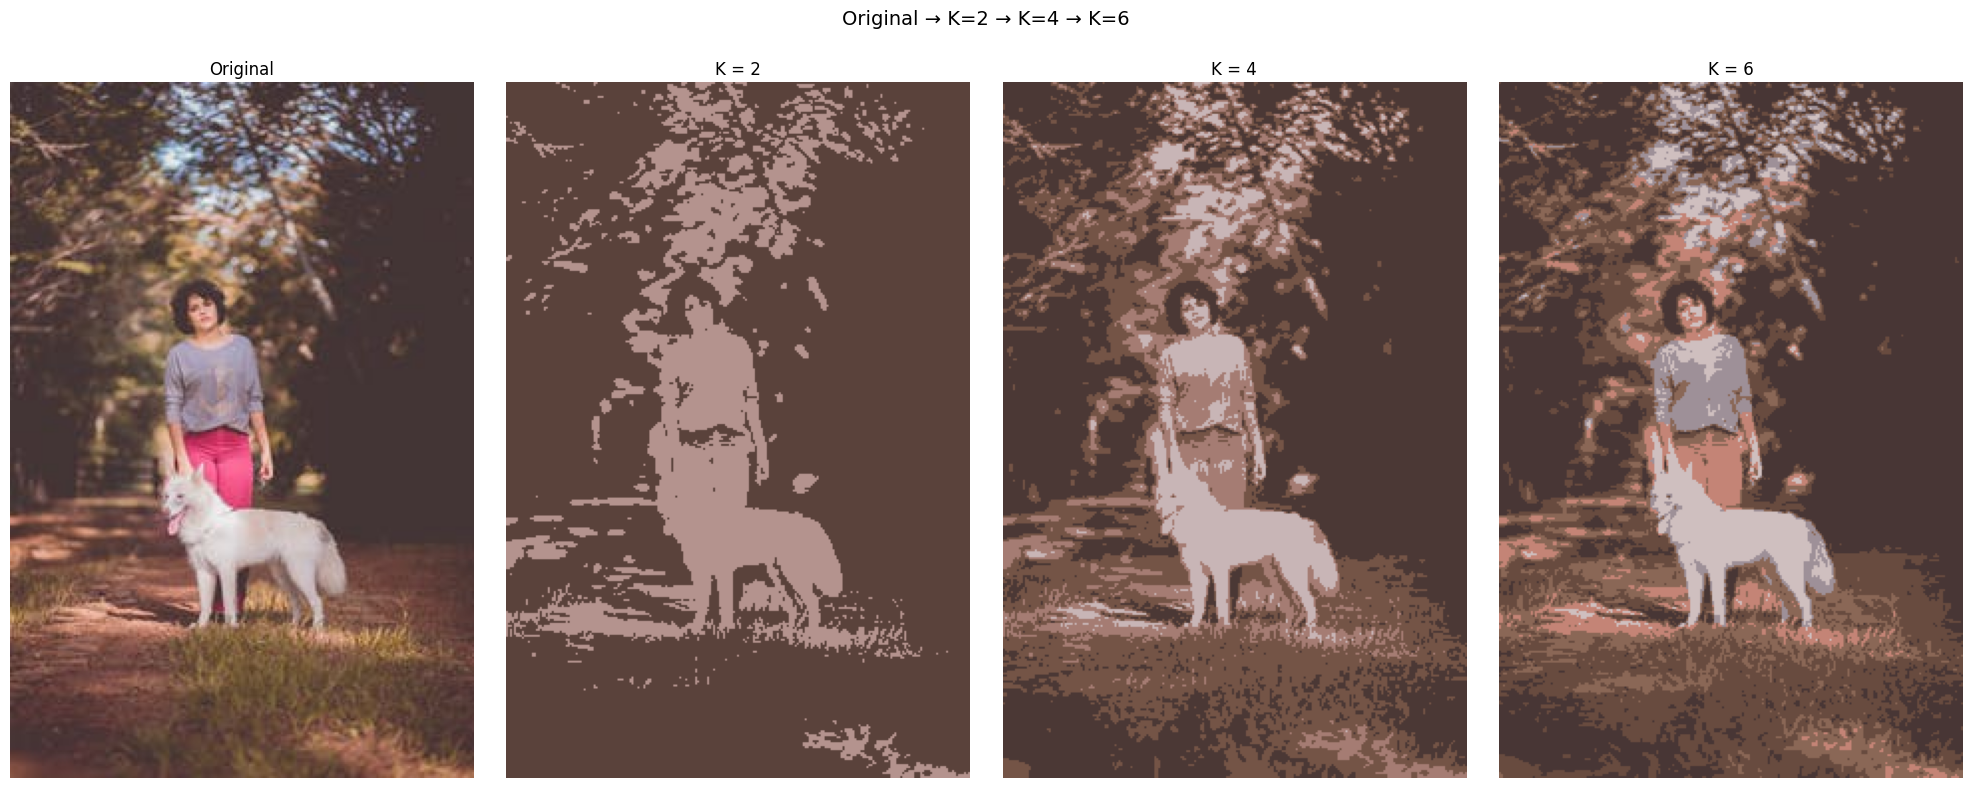

In [75]:
t9_fig, t9_axes = plt.subplots(1, 4, figsize=(20, 8))
t9_axes[0].imshow(cv2.cvtColor(t9_bgr, cv2.COLOR_BGR2RGB))
t9_axes[0].set_title("Original")
for t9_col, t9_k in enumerate(t9_k_values, start=1):
    t9_axes[t9_col].imshow(cv2.cvtColor(t9_segmented[t9_k], cv2.COLOR_BGR2RGB))
    t9_axes[t9_col].set_title(f"K = {t9_k}")
    t9_share = np.bincount(t9_labels[t9_k], minlength=t9_k) / t9_labels[t9_k].size
    t9_order = np.argsort(-t9_share)
    t9_strip = np.zeros((20, 400, 3), np.uint8)
    t9_start = 0
    for t9_c in t9_order:
        t9_end = t9_start + int(round(t9_share[t9_c] * 400))
        t9_strip[:, t9_start:t9_end] = t9_centers[t9_k][t9_c][::-1]
        t9_start = t9_end
    t9_strip[:, t9_start:] = t9_centers[t9_k][t9_order[-1]][::-1]
for t9_ax in t9_axes.ravel():
    t9_ax.axis("off")
t9_fig.suptitle("Original → K=2 → K=4 → K=6", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
t9_fig.savefig("outputs/task9_kmeans_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
for t9_k in t9_k_values:
    cv2.imwrite(f"outputs/task9_kmeans_K{t9_k}.png", t9_segmented[t9_k])

In [76]:
t9_original_colors = len(np.unique(t9_bgr.reshape(-1, 3), axis=0))
t9_rows = []
for t9_k in t9_k_values:
    t9_mse = float(np.mean((t9_segmented[t9_k].astype(np.float32) - t9_bgr.astype(np.float32)) ** 2))
    t9_psnr = 10 * np.log10(255 ** 2 / t9_mse)
    t9_rows.append({
        "K (clusters)": t9_k,
        "Distinct colors": len(np.unique(t9_segmented[t9_k].reshape(-1, 3), axis=0)),
        "Colors removed (%)": round(100 * (1 - t9_k / t9_original_colors), 3),
        "Mean squared error": round(t9_mse, 1),
        "PSNR (dB)": round(float(t9_psnr), 2),
        "Compactness (total squared distance)": f"{t9_compactness[t9_k]:.3e}",
    })
t9_summary = pd.DataFrame(t9_rows)
print("Distinct colors in the original image:", t9_original_colors)
display(t9_summary)
t9_summary.to_csv("outputs/task9_summary_table.csv", index=False)

Distinct colors in the original image: 28661


,K (clusters),Distinct colors,Colors removed (%),Mean squared error,PSNR (dB),Compactness (total squared distance)
0,2,2,99.993,513.8,21.02,1.255e+08
1,4,4,99.986,194.2,25.25,4.739e+07
2,6,6,99.979,130.4,26.98,3.182e+07


In [77]:
t9_cluster_rows = []
t9_yy, t9_xx = np.mgrid[0:t9_height, 0:t9_width]
for t9_k in t9_k_values:
    t9_lab_img = t9_labels[t9_k].reshape(t9_height, t9_width)
    for t9_c in np.argsort(-np.bincount(t9_labels[t9_k], minlength=t9_k)):
        t9_sel = t9_lab_img == t9_c
        t9_cluster_rows.append({
            "K": t9_k, "Cluster": int(t9_c),
            "Center color (R, G, B)": tuple(int(t9_v) for t9_v in t9_centers[t9_k][t9_c][::-1]),
            "Pixel share (%)": round(100 * t9_sel.mean(), 1),
            "Mean position (x, y)": (int(t9_xx[t9_sel].mean()), int(t9_yy[t9_sel].mean())),
        })
t9_cluster_table = pd.DataFrame(t9_cluster_rows)
display(t9_cluster_table)
t9_cluster_table.to_csv("outputs/task9_cluster_table.csv", index=False)

,K,Cluster,"Center color (R, G, B)",Pixel share (%),"Mean position (x, y)"
0,2,0,"(90, 66, 59)",78.7,"(118, 176)"
1,2,1,"(180, 147, 142)",21.3,"(105, 165)"
2,4,2,"(75, 56, 53)",50.6,"(127, 158)"
3,4,0,"(116, 84, 70)",27.6,"(102, 210)"
4,4,3,"(165, 124, 115)",13.3,"(102, 166)"
5,4,1,"(200, 181, 182)",8.5,"(110, 164)"
6,6,0,"(72, 54, 53)",42.8,"(132, 147)"
7,6,5,"(104, 75, 63)",26.1,"(103, 218)"
8,6,2,"(138, 103, 86)",14.6,"(101, 190)"
9,6,3,"(207, 191, 191)",5.9,"(111, 176)"


### Task 9 analysis

Original image: 28,661 distinct colors. Every K reduces that to exactly K.

| K | Distinct colors | MSE | PSNR |
|---|---|---|---|
| 2 | 2 | 513.8 | 21.0 dB |
| 4 | 4 | 194.2 | 25.3 dB |
| 6 | 6 | 130.4 | 27.0 dB |

**K = 2.** Splits into dark brown (~79%) and light pink (~21%). The light cluster lumps the dog, the woman's top, bright foliage gaps and sunlit path together -- separates bright from dark, not objects from each other.

**K = 4.** Dark area splits into two browns (shade vs. lit path/grass); light group splits into mid-pink and near-white. The dog now stands out as its own cluster.

**K = 6.** First run where distinct objects get their own color: near-white for the dog, gray-purple for the sweater, salmon for the sunlit path, three browns for foliage/shade. Closest to the original (MSE 130) at only six colors.

**What it misses.** The pink trousers never get their own cluster -- too small an area to be worth the color error, and K-Means has no notion of position, so the same cluster color reappears in unrelated spots (sky gaps, the dog).

**Overall.** Error drops steadily with diminishing returns as K grows. For a few meaningful regions, K = 4-6 is a sensible range for this photo.

---
## Task 10: Design a Segmentation System for an Unknown Image

**Methods chosen**

| Method | Parameters | Why this method |
|---|---|---|
| 1. Otsu thresholding | 5x5 Gaussian blur, auto threshold | Tests whether brightness alone splits subject from scene |
| 2. HSV color thresholding | H 160-179, S 100-255, V 100-255 (pink) | Tests whether color can isolate one object (the trousers) |
| 3. K-Means | K = 6, features = B,G,R | Tests a full color-based partition of the scene |

In [78]:
t10_bgr = cv2.imread("images/dog.jpeg")
t10_gray = cv2.cvtColor(t10_bgr, cv2.COLOR_BGR2GRAY)
t10_hsv = cv2.cvtColor(t10_bgr, cv2.COLOR_BGR2HSV)
t10_h, t10_w = t10_gray.shape
print("Image size:", t10_bgr.shape)

# ---- Method 1: Otsu thresholding
t10_blur = cv2.GaussianBlur(t10_gray, (5, 5), 0)
t10_otsu_value, t10_mask_otsu = cv2.threshold(t10_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ---- Method 2: color based thresholding in HSV
t10_lower = np.array([160, 100, 100])
t10_upper = np.array([179, 255, 255])
t10_mask_color = cv2.inRange(t10_hsv, t10_lower, t10_upper)
t10_mask_color = cv2.morphologyEx(t10_mask_color, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

# ---- Method 3: K-Means clustering
t10_pixels = t10_bgr.reshape(-1, 3).astype(np.float32)
t10_criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
cv2.setRNGSeed(42)
t10_comp, t10_lab, t10_cen = cv2.kmeans(t10_pixels, 6, None, t10_criteria, 10, cv2.KMEANS_PP_CENTERS)
t10_kmeans_img = np.uint8(t10_cen)[t10_lab.flatten()].reshape(t10_bgr.shape)

print("Otsu threshold:", t10_otsu_value, "| bright pixels:", round((t10_mask_otsu > 0).mean() * 100, 1), "%")
print("Pink mask pixels:", round((t10_mask_color > 0).mean() * 100, 2), "%")

Image size: (350, 233, 3)
Otsu threshold: 111.0 | bright pixels: 23.1 %
Pink mask pixels: 1.27 %


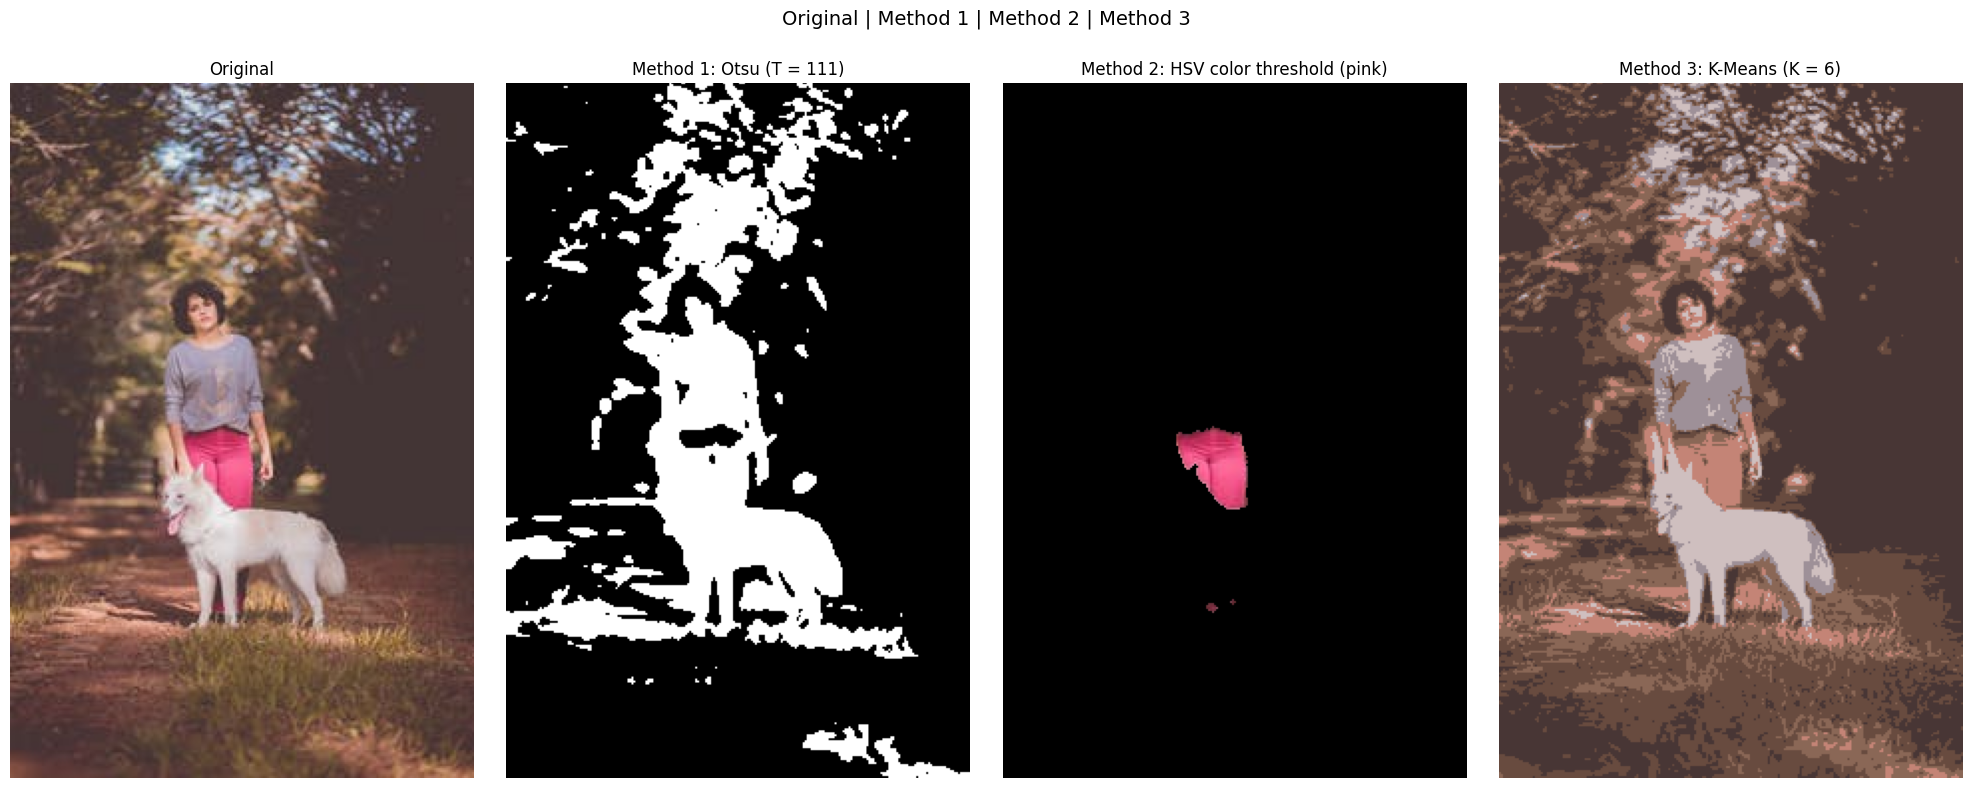

True

In [79]:
t10_fig, t10_axes = plt.subplots(1, 4, figsize=(20, 8))
t10_axes[0].imshow(cv2.cvtColor(t10_bgr, cv2.COLOR_BGR2RGB))
t10_axes[0].set_title("Original")
t10_axes[1].imshow(t10_mask_otsu, cmap="gray")
t10_axes[1].set_title(f"Method 1: Otsu (T = {t10_otsu_value:.0f})")
t10_pink_view = cv2.bitwise_and(t10_bgr, t10_bgr, mask=t10_mask_color)
t10_axes[2].imshow(cv2.cvtColor(t10_pink_view, cv2.COLOR_BGR2RGB))
t10_axes[2].set_title("Method 2: HSV color threshold (pink)")
t10_axes[3].imshow(cv2.cvtColor(t10_kmeans_img, cv2.COLOR_BGR2RGB))
t10_axes[3].set_title("Method 3: K-Means (K = 6)")
for t10_ax in t10_axes:
    t10_ax.axis("off")
t10_fig.suptitle("Original | Method 1 | Method 2 | Method 3", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
t10_fig.savefig("outputs/task10_final_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
cv2.imwrite("outputs/task10_method1_otsu.png", t10_mask_otsu)
cv2.imwrite("outputs/task10_method2_color_mask.png", t10_mask_color)
cv2.imwrite("outputs/task10_method3_kmeans.png", t10_kmeans_img)

In [80]:
t10_sens = []

# Method 1: blur, threshold
for t10_ksize in [1, 5, 11, 21]:
    t10_b = t10_gray if t10_ksize == 1 else cv2.GaussianBlur(t10_gray, (t10_ksize, t10_ksize), 0)
    t10_t, t10_m = cv2.threshold(t10_b, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t10_sens.append({"Method": "Otsu", "Parameter": "blur kernel", "Value": t10_ksize,
                     "Threshold picked": t10_t, "Foreground (%)": round((t10_m > 0).mean() * 100, 1)})

for t10_shift in [-30, 30]:
    t10_m = cv2.threshold(t10_blur, t10_otsu_value + t10_shift, 255, cv2.THRESH_BINARY)[1]
    t10_sens.append({"Method": "Otsu", "Parameter": "threshold shift", "Value": t10_shift,
                     "Threshold picked": t10_otsu_value + t10_shift, "Foreground (%)": round((t10_m > 0).mean() * 100, 1)})

# Method 2: lower hue limit, minimum saturation, minimum value
for t10_name, t10_values in [("lower hue", [150, 160, 168]), ("min saturation", [40, 100, 160]), ("min value", [60, 100, 160])]:
    for t10_val in t10_values:
        t10_lo = np.array([160, 100, 100])
        t10_idx = {"lower hue": 0, "min saturation": 1, "min value": 2}[t10_name]
        t10_lo[t10_idx] = t10_val
        t10_m = cv2.inRange(t10_hsv, t10_lo, t10_upper)
        t10_sens.append({"Method": "HSV color", "Parameter": t10_name, "Value": t10_val,
                         "Threshold picked": "-", "Foreground (%)": round((t10_m > 0).mean() * 100, 2)})

# Method 3: number of clusters (K)
for t10_k in [3, 6, 9]:
    cv2.setRNGSeed(42)
    t10_unused, t10_l, t10_c = cv2.kmeans(t10_pixels, t10_k, None, t10_criteria, 10, cv2.KMEANS_PP_CENTERS)
    t10_rec = np.uint8(t10_c)[t10_l.flatten()].reshape(t10_bgr.shape)
    t10_mse = float(np.mean((t10_rec.astype(np.float32) - t10_bgr.astype(np.float32)) ** 2))
    t10_sens.append({"Method": "K-Means", "Parameter": "K", "Value": t10_k,
                     "Threshold picked": "-", "Foreground (%)": f"MSE = {t10_mse:.0f}"})

t10_sens_table = pd.DataFrame(t10_sens)
display(t10_sens_table)
t10_sens_table.to_csv("outputs/task10_parameter_sensitivity.csv", index=False)

,Method,Parameter,Value,Threshold picked,Foreground (%)
0,Otsu,blur kernel,1,113.0,22.4
1,Otsu,blur kernel,5,111.0,23.1
2,Otsu,blur kernel,11,108.0,24.7
3,Otsu,blur kernel,21,105.0,26.9
4,Otsu,threshold shift,-30,81.0,46.5
5,Otsu,threshold shift,30,141.0,12.0
6,HSV color,lower hue,150,-,1.33
7,HSV color,lower hue,160,-,1.33
8,HSV color,lower hue,168,-,1.33
9,HSV color,min saturation,40,-,2.32


### Task 10 analysis

**Method 1 -- Otsu (T = 111)**
1. *Assumption:* the histogram has two groups -- dark background, bright object.
2. *Finds:* the dog and the woman's bright top/clothing (23.1% of the image).
3. *Misses:* also marks bright sky gaps and sunlit path as foreground; can't tell the woman from the dog, and her darker trousers leave a hole.
4. *Most sensitive parameter:* the threshold itself -- a +/-30 shift moves foreground from 23.1% to 46.5% (lower) or 12.0% (higher). Blur kernel barely matters (22.4% -> 26.9%).

**Method 2 -- HSV color (pink)**
1. *Assumption:* the target object's color differs from everything else in the scene.
2. *Finds:* the trousers cleanly (1.3% of the image).
3. *Misses:* a few path specks, the part of the trousers hidden behind the dog, and the dog/woman entirely (no distinguishing hue).
4. *Most sensitive parameter:* minimum saturation (2.32% at S>=40 down to 0.77% at S>=160); min value matters a little; lower-hue limit made no difference between 150-168.

**Method 3 -- K-Means (K = 6)**
1. *Assumption:* regions of interest differ in average color and are compact in color space.
2. *Finds:* the dog, the sweater, the sunlit path and foliage/shade as separate clusters.
3. *Misses:* the pink trousers merge into the salmon path cluster; the same cluster color appears in disconnected spots since position isn't used.
4. *Most sensitive parameter:* K -- reconstruction error falls from 281 (K=3) to 130 (K=6) to 86 (K=9), changing which objects get their own cluster.

**Technical conclusion.** K-Means (K=6) gives the most meaningful regions -- it's the only method that partitions the whole scene (dog, top, path, foliage all separable). Otsu fails because brightness alone can't separate the subject from the bright sky gaps and path. The HSV mask is the cleanest result but only for one small object. Isolating just the dog would need a combination -- e.g. K-Means clusters filtered by position or component size.